<a href="https://colab.research.google.com/github/Nikhil5566/Data-Science-Portfolio-Projects/blob/main/Sudan%20Food%20Security%20Market%20Prices%20(2010-2026).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Sudan Food Security: Market Prices (2010 - 2026)

## Sudan's Food Crisis: A Deep Dive into Market Prices (2001 - 2026)

This analysis dives into a comprehensive dataset tracking food market prices across Sudan from 2001 to 2026, offering a stark picture of the challenges faced by its population. The data covers various commodities like cereals, meats, oils, and vegetables across multiple regions and markets, recorded in both Sudanese Pounds (SDG) and US Dollars (USD).

The Crushing Reality of Hyperinflation:

One of the most striking findings is the severe hyperinflationary decoupling of local and USD prices. While in a healthy economy, local and international prices for goods tend to move in tandem, Sudan's local currency (SDG) has fundamentally collapsed. Our analysis shows a weak correlation between local and USD prices, meaning that even if a commodity's global USD value is stable, its price in SDG is skyrocketing. This is starkly illustrated by the Implicit Exchange Rate, which has seen a catastrophic structural break post-2019, jumping from an average of 5.22 SDG/USD pre-2019 to 431.91 SDG/USD post-2019. This means people's purchasing power in local currency has been obliterated, making basic food unaffordable.

Geographic Inequity and Conflict Premiums:

Where you live in Sudan significantly dictates your ability to afford food. Our spatial analysis using ANOVA for staple cereals revealed statistically significant differences in food prices across states. This points to spatial inequity and potential conflict premiums, where regions affected by conflict or supply chain bottlenecks experience much higher localized prices. This isn't just about hardship; it's about life and death depending on geography.

Unstable Supply Chains and Seasonal Shocks:

Not all food categories are equally vulnerable. The Coefficient of Variation showed that cereals and tubers, miscellaneous foods, and vegetables are the most volatile, experiencing the most violent price swings. This highlights fragile supply chains susceptible to shocks. Furthermore, the 'Lean Season' diagnostic confirmed statistically significant seasonality for staple foods like Sorghum. Prices reliably surge just before harvests and drop afterwards, a critical cycle that humanitarian aid must anticipate with pre-emptive food stockpiling.

Fragmented Markets:

Intriguingly, our Granger Causality test indicated that price shocks in the central hub of Khartoum do not reliably predict price shocks in peripheral regions like Darfur. This suggests severe market isolation and supply-chain fragmentation, likely due to blocked roads or insecurity, preventing efficient price transmission and exacerbating local food crises.

An Early Warning System for Crisis:

Finally, we've built a robust early warning system using machine learning models (XGBoost outperformed Random Forest) to predict future food prices. This model, driven by factors like past prices, commodity type, and geographic location, can forecast price movements with high accuracy. This tool is invaluable for humanitarian organizations to identify and respond to potential food crises proactively.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Installing Kaggle API
!pip install -q kaggle

# Uploading kaggle.json
from google.colab import files
files.upload()

# Moving kaggle.json to ~/.kaggle/
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

# Downloading the dataset using Kaggle API
!kaggle datasets download -d samirmidris/sudan-food-security-market-prices-2010-2026

# Unziping the downloaded file
!unzip sudan-food-security-market-prices-2010-2026.zip

Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/samirmidris/sudan-food-security-market-prices-2010-2026
License(s): CC-BY-SA-4.0
  0% 0.00/130k [00:00<?, ?B/s]
100% 130k/130k [00:00<00:00, 492MB/s]
Archive:  sudan-food-security-market-prices-2010-2026.zip
  inflating: wfp_food_prices_sdn.csv  


# Data Inspection

In [ ]:
df = pd.read_csv('wfp_food_prices_sdn.csv')
df.head(11)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
0,2001-01-15,Blue Nile,Damazin,Damazin,1026,11.79,34.36,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,46.00,17.76
1,2001-01-15,Gedaref,Al Gedaref Rural,El Gedarif,2580,14.04,35.38,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,51.67,19.95
2,2001-01-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,63.90,24.67
3,2001-01-15,North Kordofan,Shiekan,El Obeid,1029,13.19,30.22,cereals and tubers,Millet,73,90 KG,actual,Wholesale,SDG,66.25,25.58
4,2001-02-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Wheat,84,90 KG,actual,Wholesale,SDG,82.36,31.80
5,2001-02-15,North Kordofan,Shiekan,El Obeid,1029,13.19,30.22,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,48.14,18.59
6,2001-03-15,Blue Nile,Damazin,Damazin,1026,11.79,34.36,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,45.00,17.37
7,2001-03-15,Gedaref,Al Gedaref Rural,El Gedarif,2580,14.04,35.38,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,48.98,18.91
8,2001-03-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Millet,73,90 KG,actual,Wholesale,SDG,73.22,28.27
9,2001-03-15,Khartoum,Jebal Aulya,Khartoum,2588,15.51,32.54,cereals and tubers,Sorghum (white),135,90 KG,actual,Wholesale,SDG,58.00,22.39


In [ ]:
df.tail(11)

,date,admin1,admin2,market,market_id,latitude,longitude,category,commodity,commodity_id,unit,priceflag,pricetype,currency,price,usdprice
14627,2026-01-15,West Kordofan,El Salam,El Fula,1823,11.73,28.36,miscellaneous food,Sugar,97,KG,actual,Retail,SDG,5000.0,8.33
14628,2026-01-15,West Kordofan,El Salam,El Fula,1823,11.73,28.36,oil and fats,Oil (vegetable),96,L,actual,Retail,SDG,4000.0,6.67
14629,2026-01-15,West Kordofan,El Salam,El Fula,1823,11.73,28.36,pulses and nuts,"Beans (fava, egyptian)",1178,KG,actual,Retail,SDG,9625.0,16.04
14630,2026-01-15,West Kordofan,El Salam,El Fula,1823,11.73,28.36,vegetables and fruits,Onions,173,KG,actual,Retail,SDG,2688.0,4.48
14631,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,cereals and tubers,Millet,73,3.5 KG,actual,Retail,SDG,6059.0,10.10
14632,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,cereals and tubers,Sorghum,65,3 KG,actual,Retail,SDG,3050.0,5.08
14633,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,miscellaneous food,Salt (iodised),334,KG,actual,Retail,SDG,1188.0,1.98
14634,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,miscellaneous food,Sugar,97,KG,actual,Retail,SDG,3438.0,5.73
14635,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,pulses and nuts,"Beans (fava, egyptian)",1178,KG,actual,Retail,SDG,6000.0,1.00
14636,2026-01-15,White Nile,Kosti,Kosti,1032,13.17,32.67,vegetables and fruits,Onions,173,KG,actual,Retail,SDG,1250.0,2.08


In [ ]:
df.shape

(14638, 16)

In [ ]:
df.columns

Index(['date', 'admin1', 'admin2', 'market', 'market_id', 'latitude',
       'longitude', 'category', 'commodity', 'commodity_id', 'unit',
       'priceflag', 'pricetype', 'currency', 'price', 'usdprice'],
      dtype='object')

In [ ]:
df.dtypes

,0
date,object
admin1,object
admin2,object
market,object
market_id,int64
latitude,float64
longitude,float64
category,object
commodity,object
commodity_id,int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14638 entries, 0 to 14637
Data columns (total 16 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   date          14638 non-null  object 
 1   admin1        14638 non-null  object 
 2   admin2        14638 non-null  object 
 3   market        14638 non-null  object 
 4   market_id     14638 non-null  int64  
 5   latitude      14638 non-null  float64
 6   longitude     14638 non-null  float64
 7   category      14638 non-null  object 
 8   commodity     14638 non-null  object 
 9   commodity_id  14638 non-null  int64  
 10  unit          14638 non-null  object 
 11  priceflag     14638 non-null  object 
 12  pricetype     14638 non-null  object 
 13  currency      14638 non-null  object 
 14  price         14638 non-null  float64
 15  usdprice      14638 non-null  float64
dtypes: float64(4), int64(2), object(10)
memory usage: 1.8+ MB


In [ ]:
df.describe(include = 'all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
date,14638,301,2025-04-15,149,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admin1,14638,18,South Kordofan,1344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admin2,14638,18,Kadugli,1344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market,14638,18,Kadugli,1344,NaN,NaN,NaN,NaN,NaN,NaN,NaN
market_id,14638.0,NaN,NaN,NaN,1538.442,1392.020193,1025.0,1028.0,1031.0,1034.0,9031.0
latitude,14638.0,NaN,NaN,NaN,13.758815,2.480873,11.02,11.79,13.19,14.4,19.62
longitude,14638.0,NaN,NaN,NaN,30.104069,4.618811,22.45,25.35,30.22,34.36,37.22
category,14638,8,cereals and tubers,8219,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commodity,14638,16,Millet,2830,NaN,NaN,NaN,NaN,NaN,NaN,NaN
commodity_id,14638.0,NaN,NaN,NaN,204.32887,244.442176,58.0,73.0,97.0,238.0,1178.0


In [ ]:
df.isnull().sum()

,0
date,0
admin1,0
admin2,0
market,0
market_id,0
latitude,0
longitude,0
category,0
commodity,0
commodity_id,0


In [ ]:
df.duplicated().sum()

np.int64(0)

# Univariate Analysis

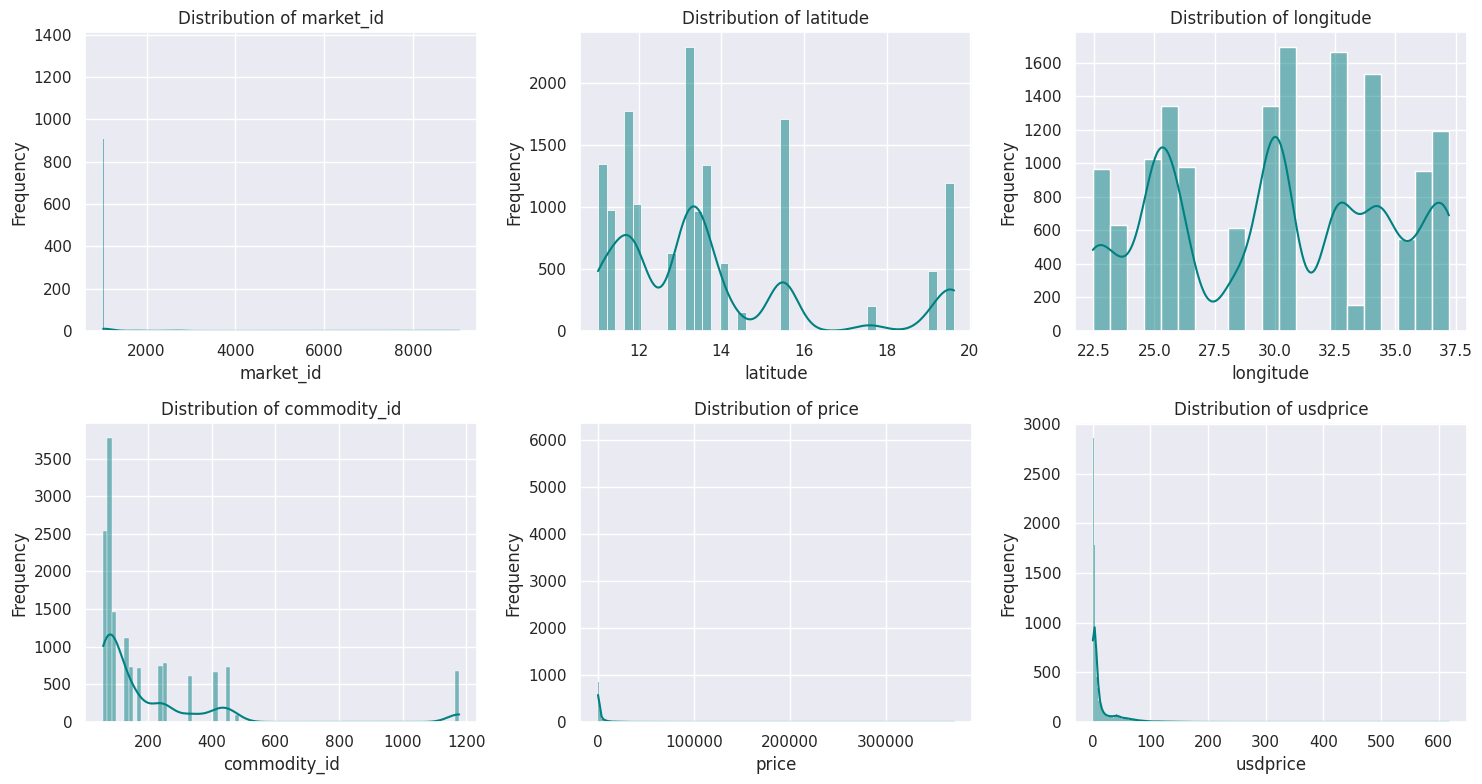

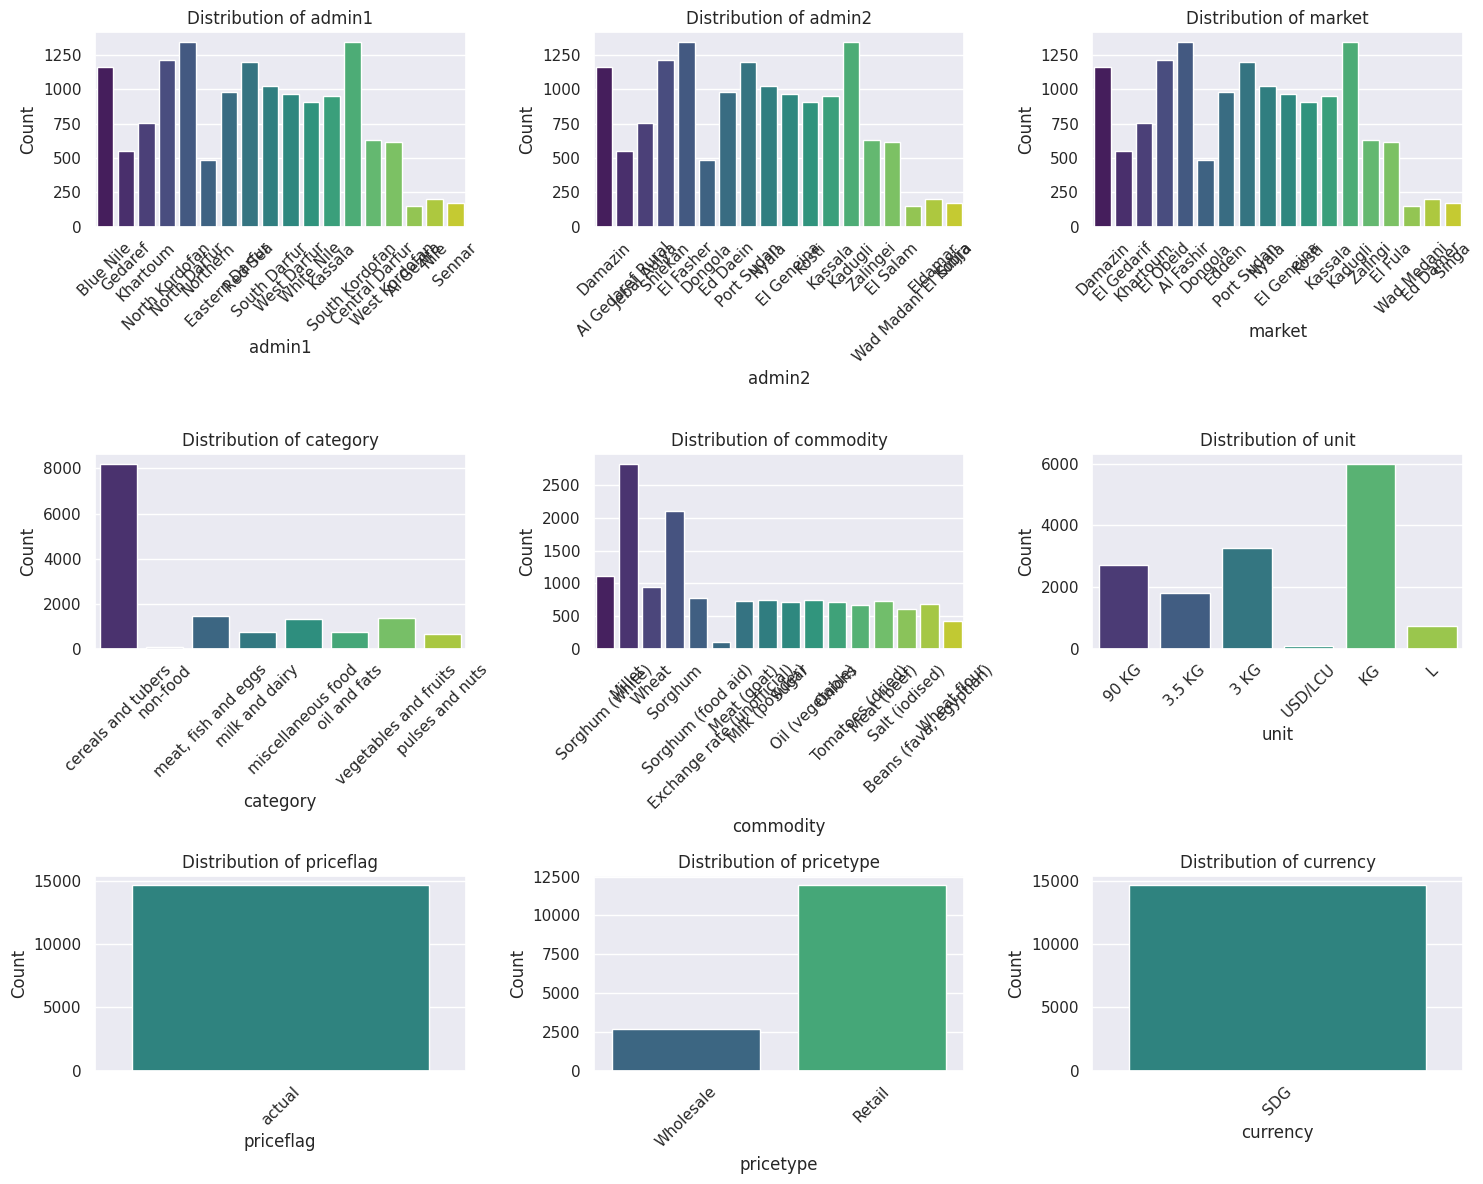

--- Categorical Value Counts ---

Value counts for admin1:
admin1
South Kordofan    1344
North Darfur      1340
North Kordofan    1210
Red Sea           1194
Blue Nile         1158
South Darfur      1024
Eastern Darfur     978
West Darfur        967
Kassala            952
White Nile         907
Khartoum           755
Central Darfur     631
West Kordofan      617
Gedaref            551
Northern           486
Nile               199
Sennar             173
Al Gezira          152
Name: count, dtype: int64

Value counts for admin2:
admin2
Kadugli                1344
El Fasher              1340
Shiekan                1210
Port Sudan             1194
Damazin                1158
Nyala                  1024
Ed Daein                978
El Geneina              967
Kassala                 952
Kosti                   907
Jebal Aulya             755
Zalingei                631
El Salam                617
Al Gedaref Rural        551
Dongola                 486
Eldamar                 199
Sinjja       

In [ ]:
import math

# --- 1. Numerical Columns (Histograms in a Grid) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

if len(numerical_cols) > 0:
    # Defining grid size
    num_plots = len(numerical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(numerical_cols):
        sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal') # Added color
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Frequency')

    # Hiding any unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# --- 2. Categorical Columns (Countplots in a Grid) ---
# Filtering out columns with too many unique values (like IDs) to avoid messy plots
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]

if len(categorical_cols) > 0:
    # Defining grid size
    num_plots = len(categorical_cols)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    # Iterating and plot
    for i, col in enumerate(categorical_cols):
        sns.countplot(data=df, x=col, ax=axes[i], palette='viridis', hue=col, legend=False) # Added palette
        axes[i].set_title(f'Distribution of {col}')
        axes[i].set_xlabel(col)
        axes[i].set_ylabel('Count')
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

     # --- 3. Value Counts (Text Output) ---
    print("--- Categorical Value Counts ---")
    for col in categorical_cols:
        print(f"\nValue counts for {col}:")
        print(df[col].value_counts())
else:
    print("No categorical columns found (or all have high cardinality).")

# Bivariate Analysis

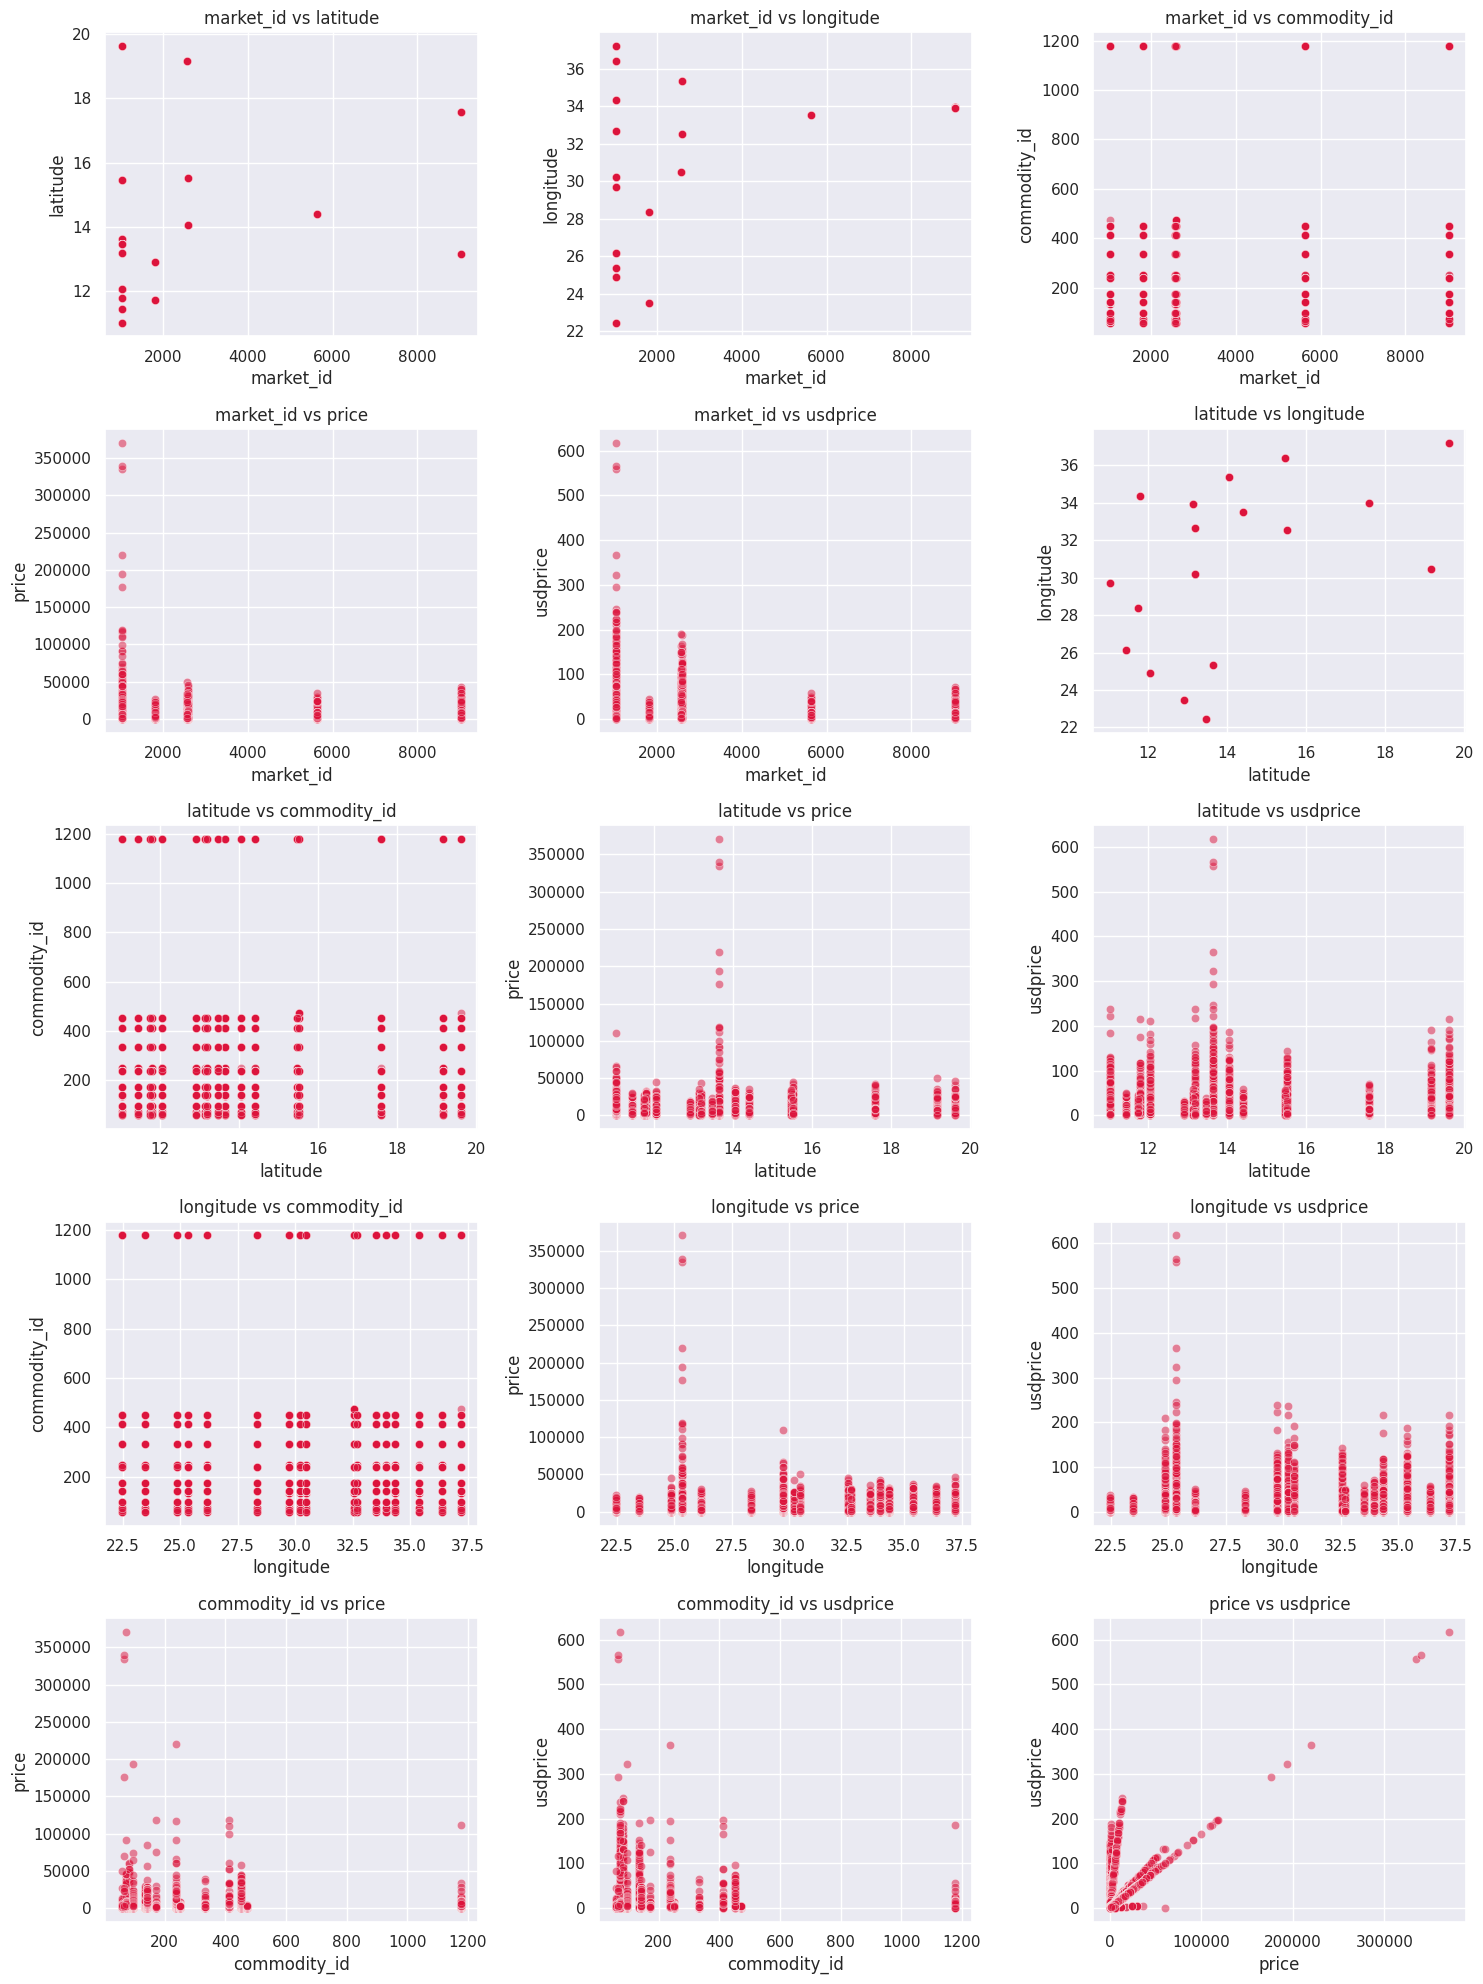

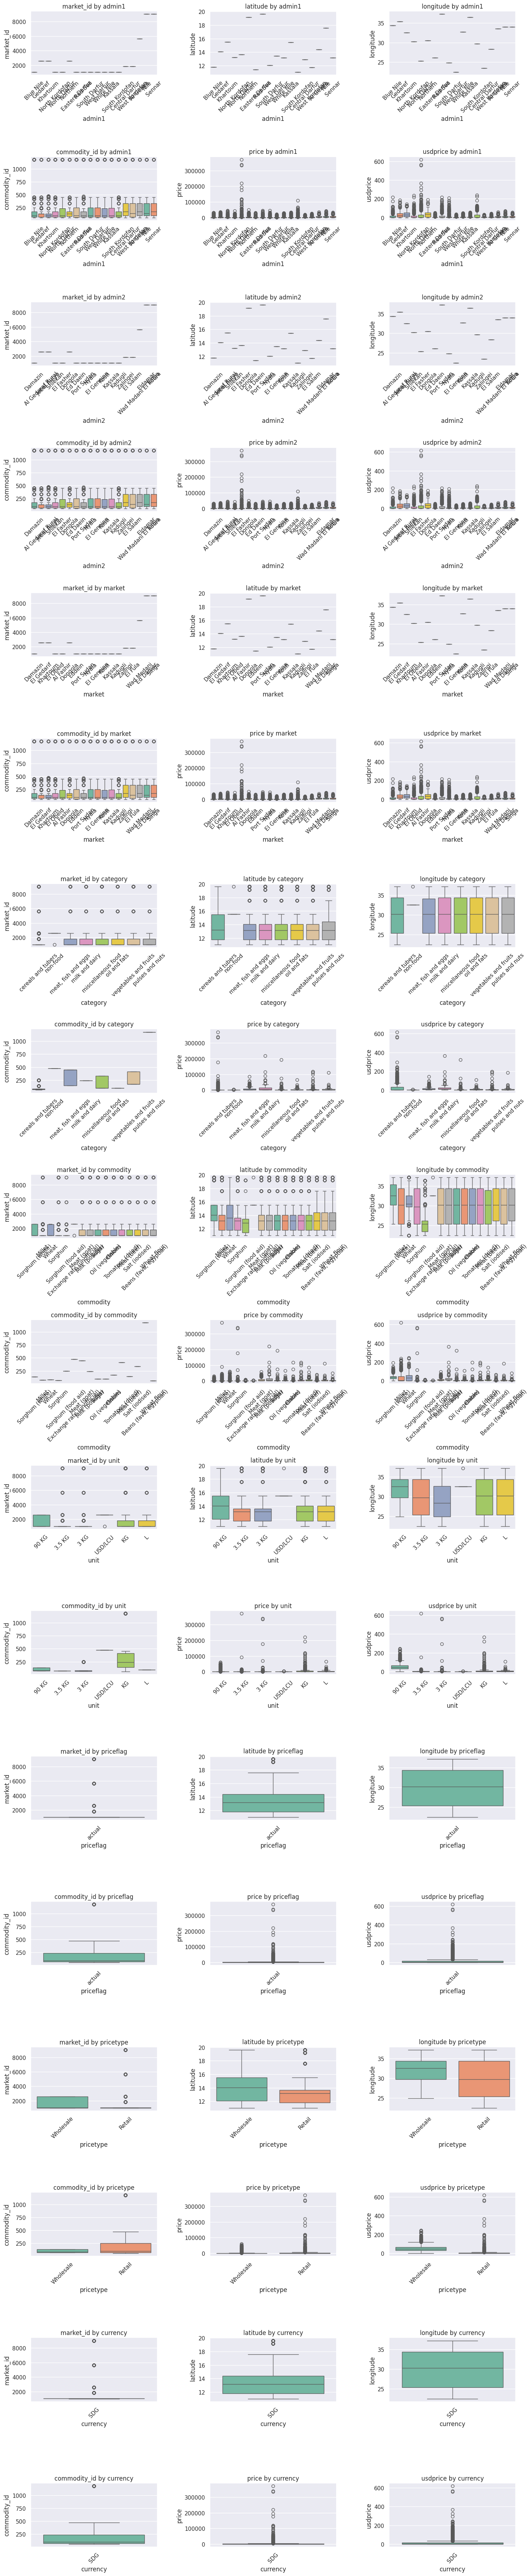

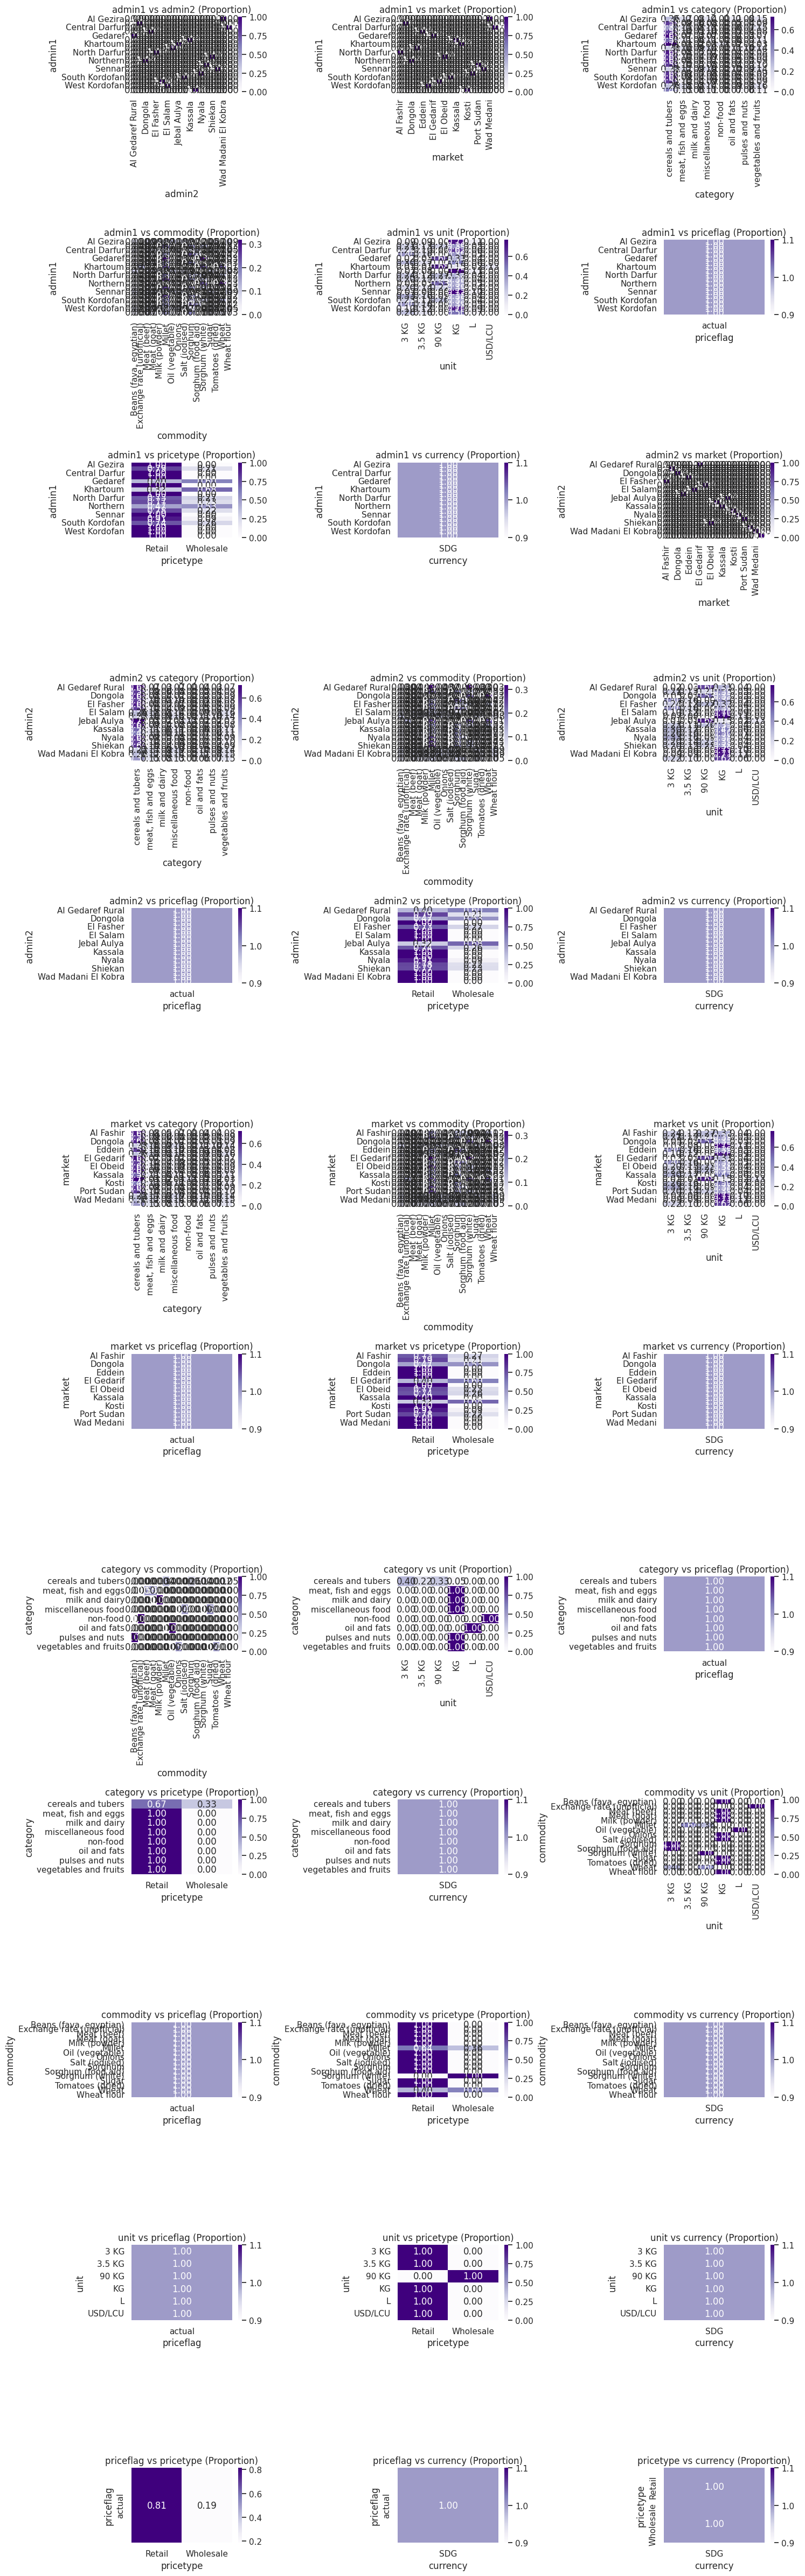

In [ ]:
import itertools

# --- 1. Numerical-Numerical Relationships (Scatter Plots) ---
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all unique pairs of numerical columns
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(num_pairs) > 0:
    # Defining grid size
    num_plots = len(num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (col1, col2) in enumerate(num_pairs):
        sns.scatterplot(data=df, x=col1, y=col2, ax=axes[i], alpha=0.5, color='crimson') # Added color
        axes[i].set_title(f'{col1} vs {col2}')
        axes[i].set_xlabel(col1)
        axes[i].set_ylabel(col2)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("Not enough numerical columns for scatter plots.")


# --- 2. Categorical-Numerical Relationships (Box Plots) ---
# Excluding high cardinality columns
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 20]
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()

# Generating all pairs of (Categorical, Numerical)
cat_num_pairs = list(itertools.product(categorical_cols, numerical_cols))

if len(cat_num_pairs) > 0:
    # Defining grid size
    num_plots = len(cat_num_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    # Creating figure and axes
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    # Iterating through pairs and plot
    for i, (cat_col, num_col) in enumerate(cat_num_pairs):
        sns.boxplot(data=df, x=cat_col, y=num_col, ax=axes[i], palette='Set2', hue=cat_col, legend=False)
        axes[i].set_title(f'{num_col} by {cat_col}')
        axes[i].set_xlabel(cat_col)
        axes[i].set_ylabel(num_col)
        axes[i].tick_params(axis='x', rotation=45)

    # Hiding unused subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()
else:
    print("No categorical-numerical pairs found.")


# --- 3. Categorical-Categorical Relationships (Heatmaps) ---
# Generating pairs of categorical columns
cat_pairs = list(itertools.combinations(categorical_cols, 2))

if len(cat_pairs) > 0:
    num_plots = len(cat_pairs)
    num_cols = 3
    num_rows = math.ceil(num_plots / num_cols)

    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))

    if num_plots == 1:
        axes = [axes]
    else:
        axes = axes.flatten()

    for i, (col1, col2) in enumerate(cat_pairs):
        # Creating a cross-tabulation
        crosstab = pd.crosstab(df[col1], df[col2], normalize='index')
        sns.heatmap(crosstab, annot=True, fmt='.2f', cmap='Purples', ax=axes[i])
        axes[i].set_title(f'{col1} vs {col2} (Proportion)')

    for j in range(i + 1, len(axes)):
        axes[j].axis('off')

    plt.tight_layout()
    plt.show()

# Multivariate Analysis


Analyzing relationships with Hue: category...


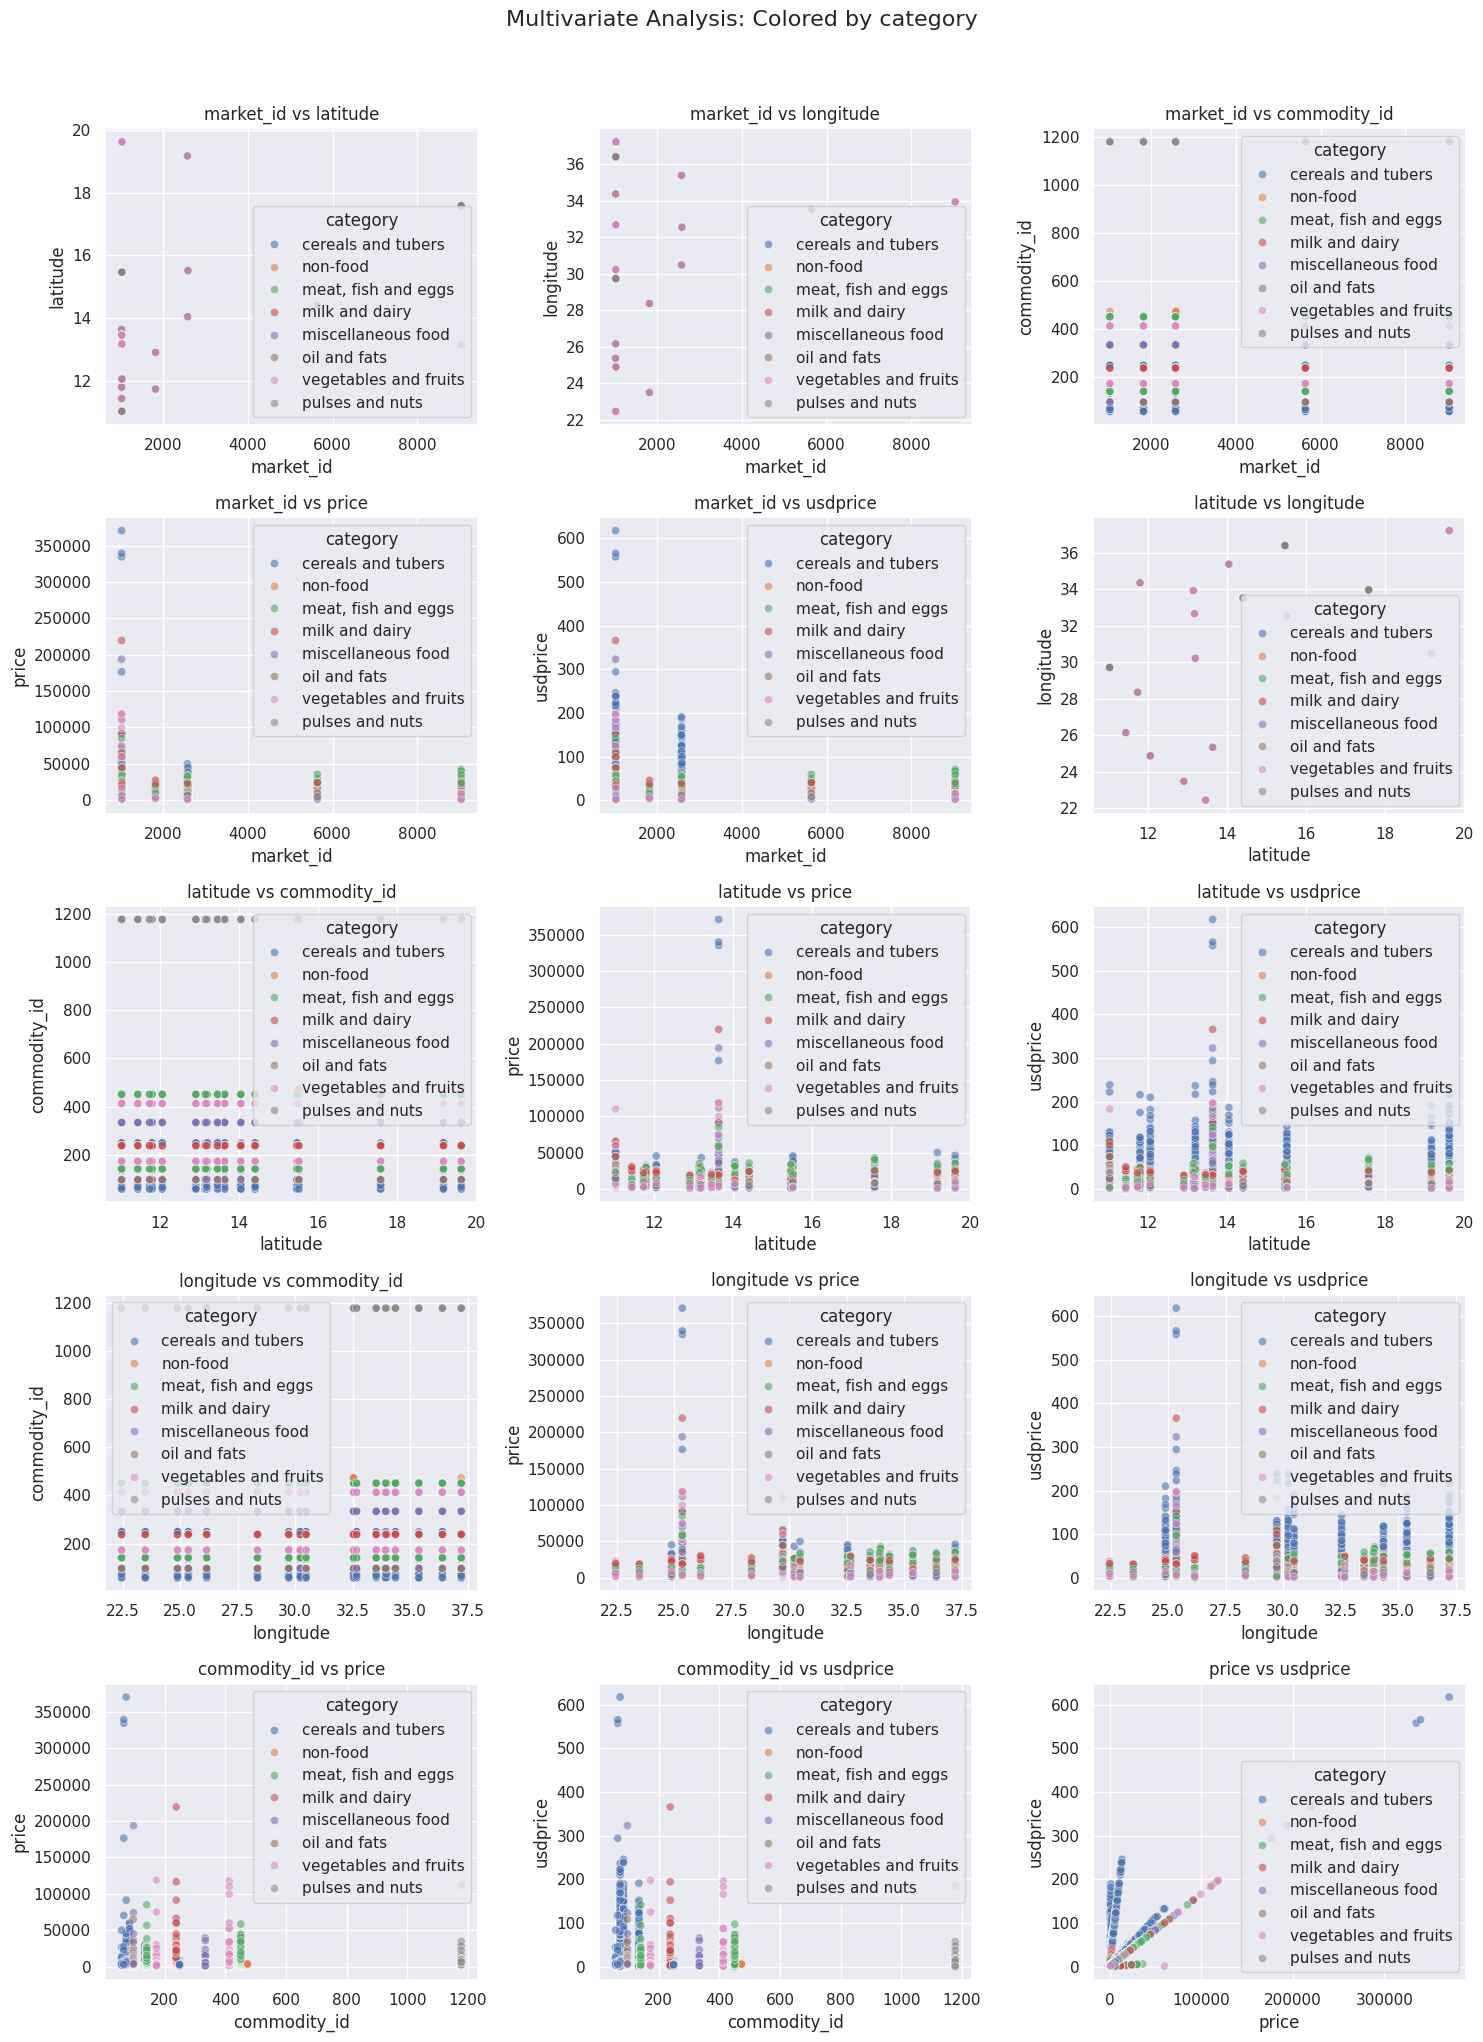


Analyzing relationships with Hue: unit...


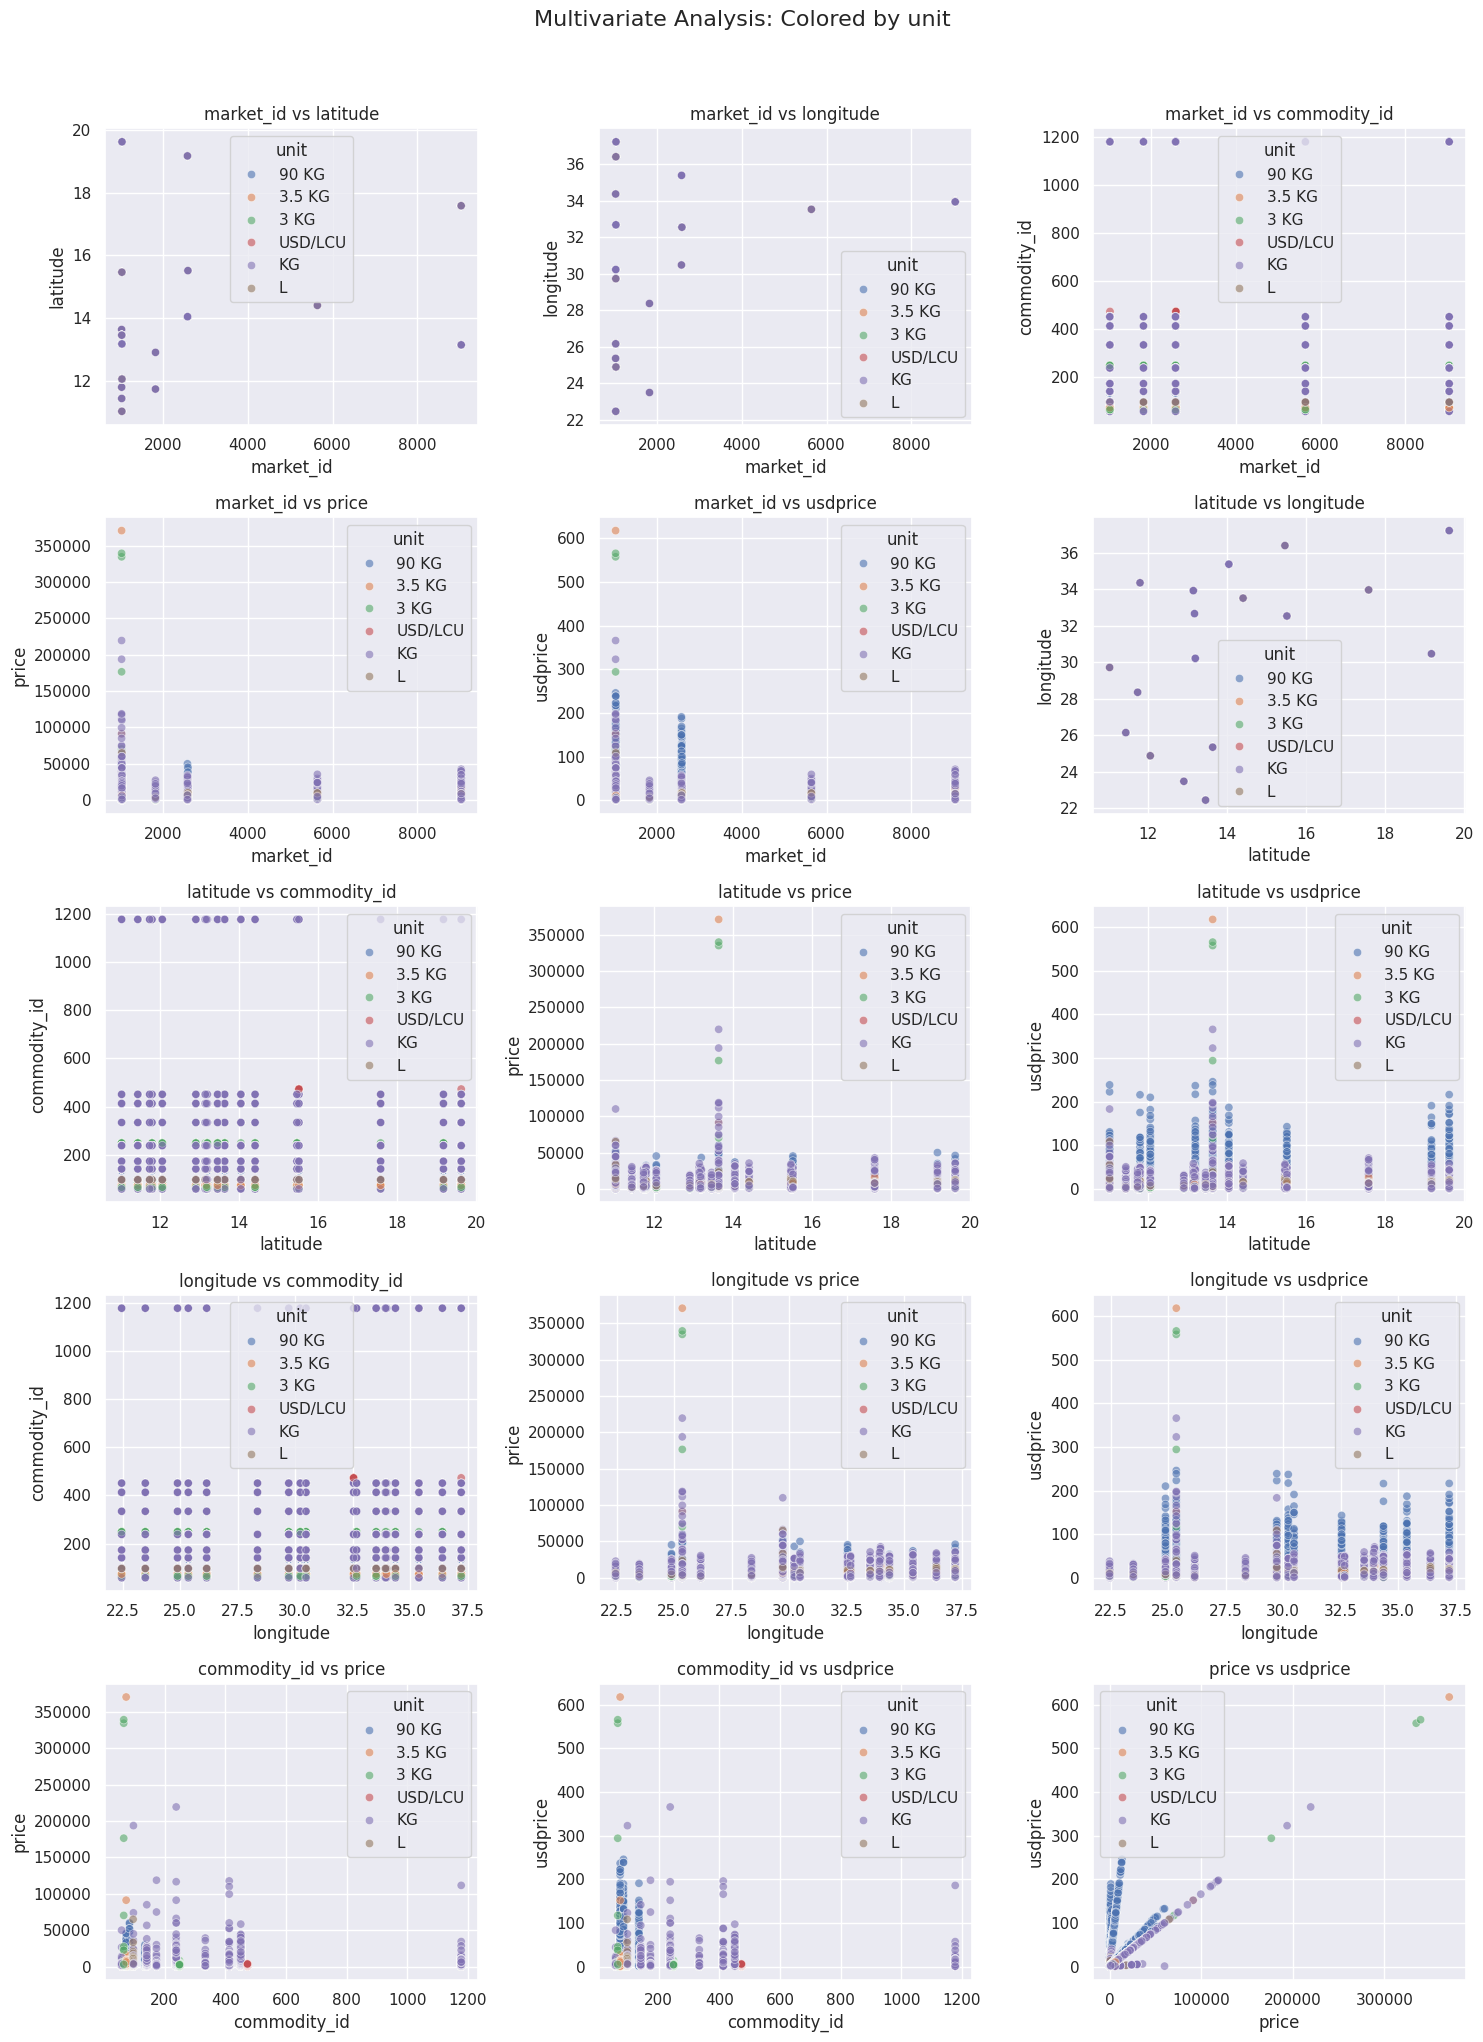


Analyzing relationships with Hue: priceflag...


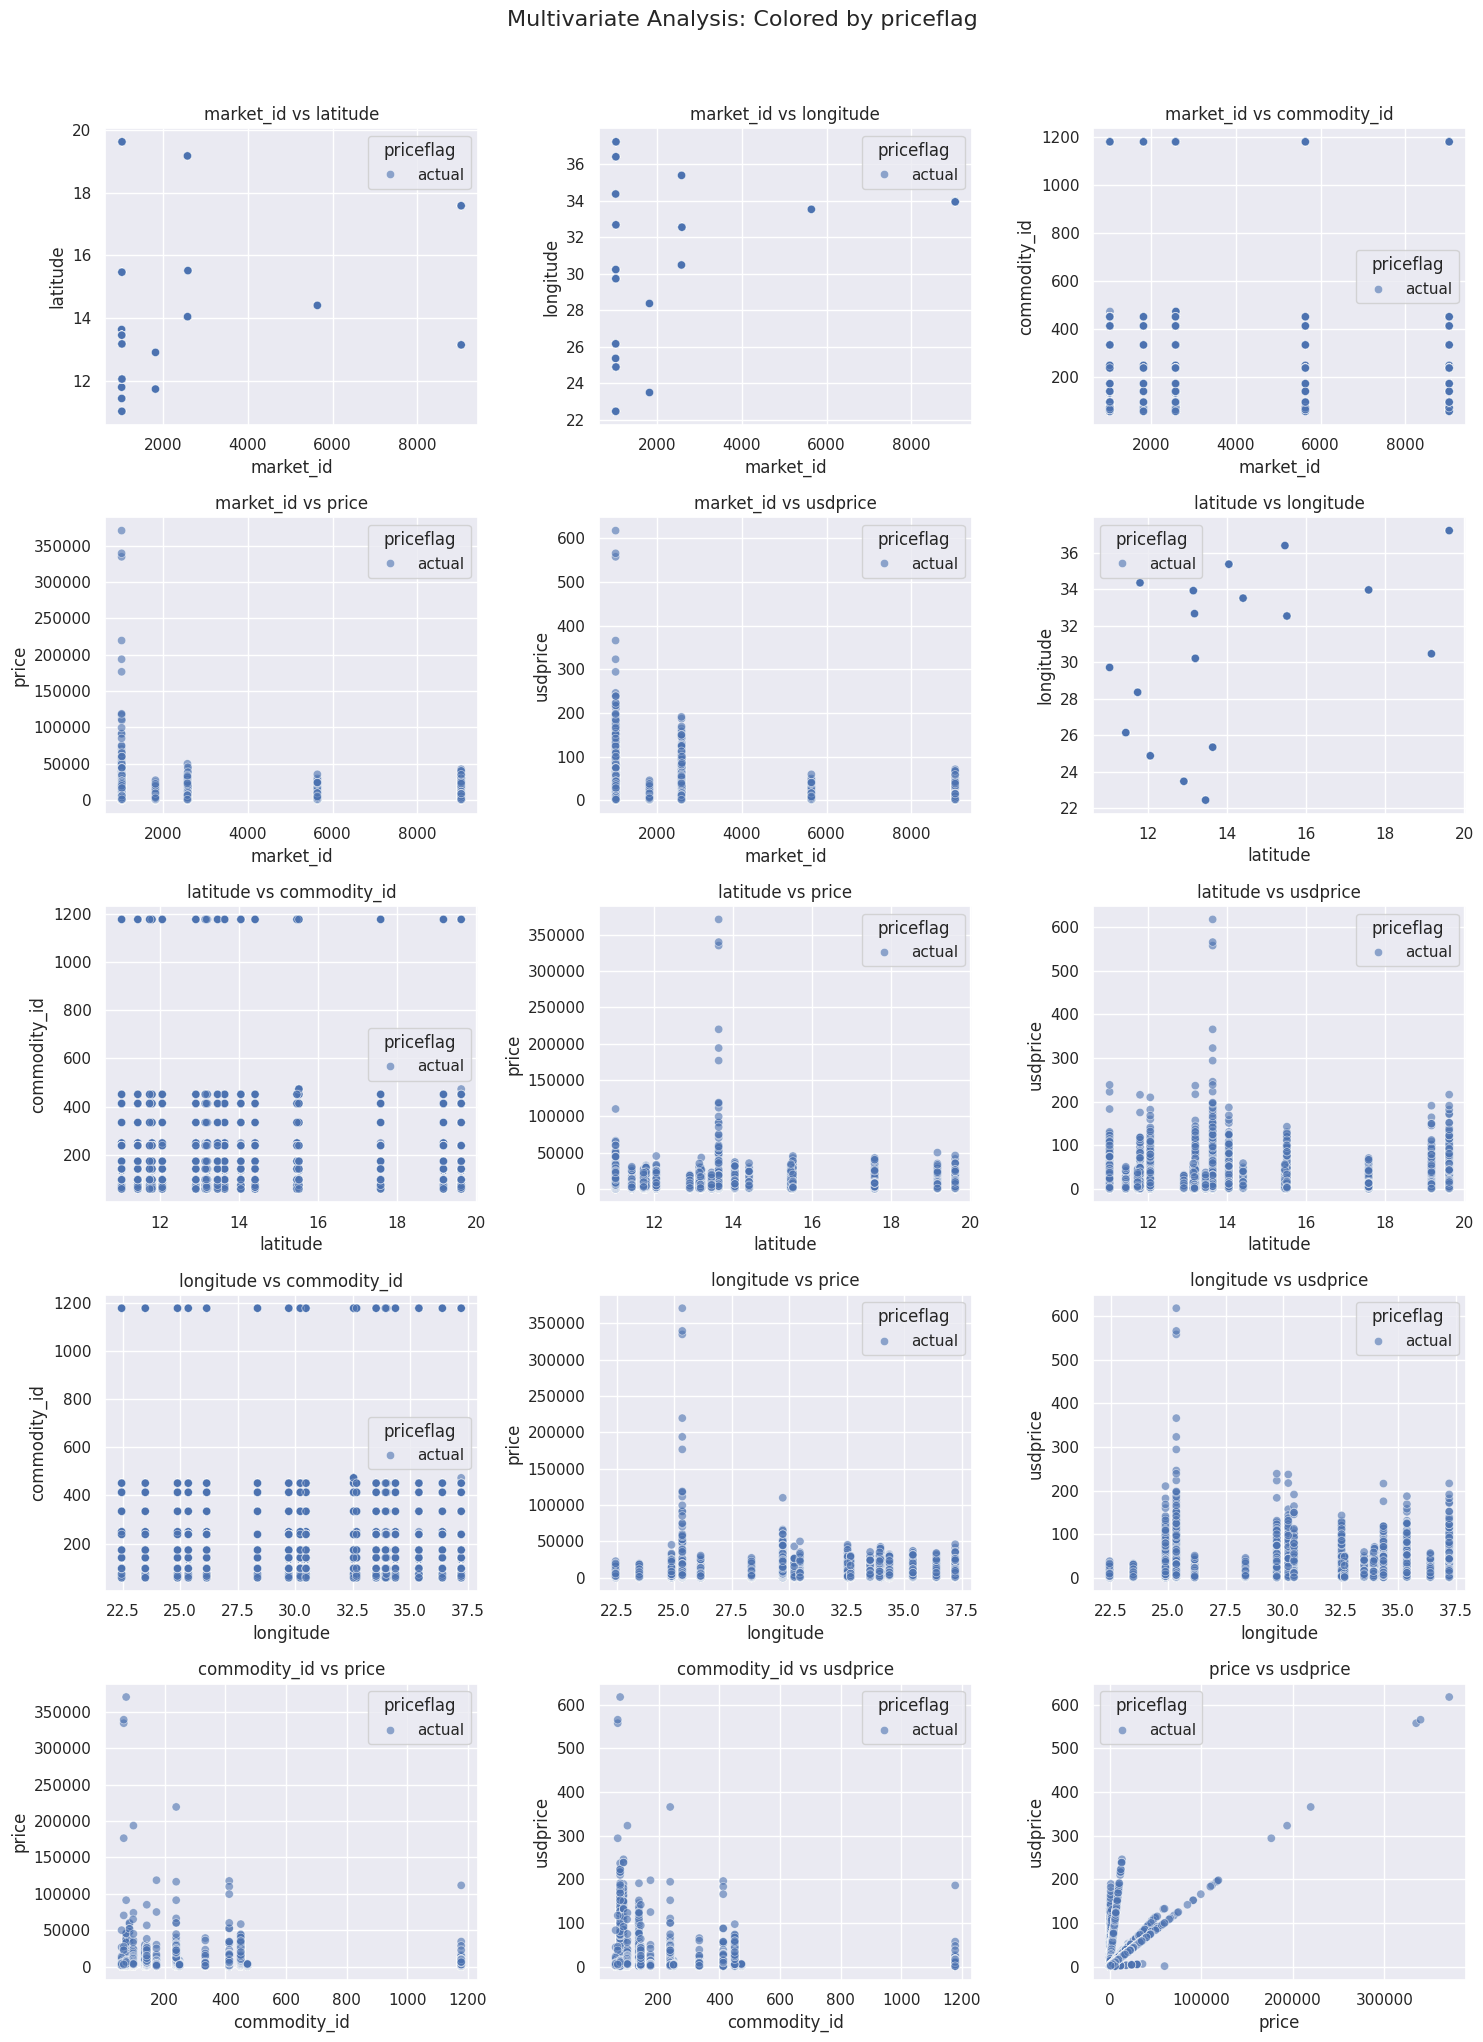


Analyzing relationships with Hue: pricetype...


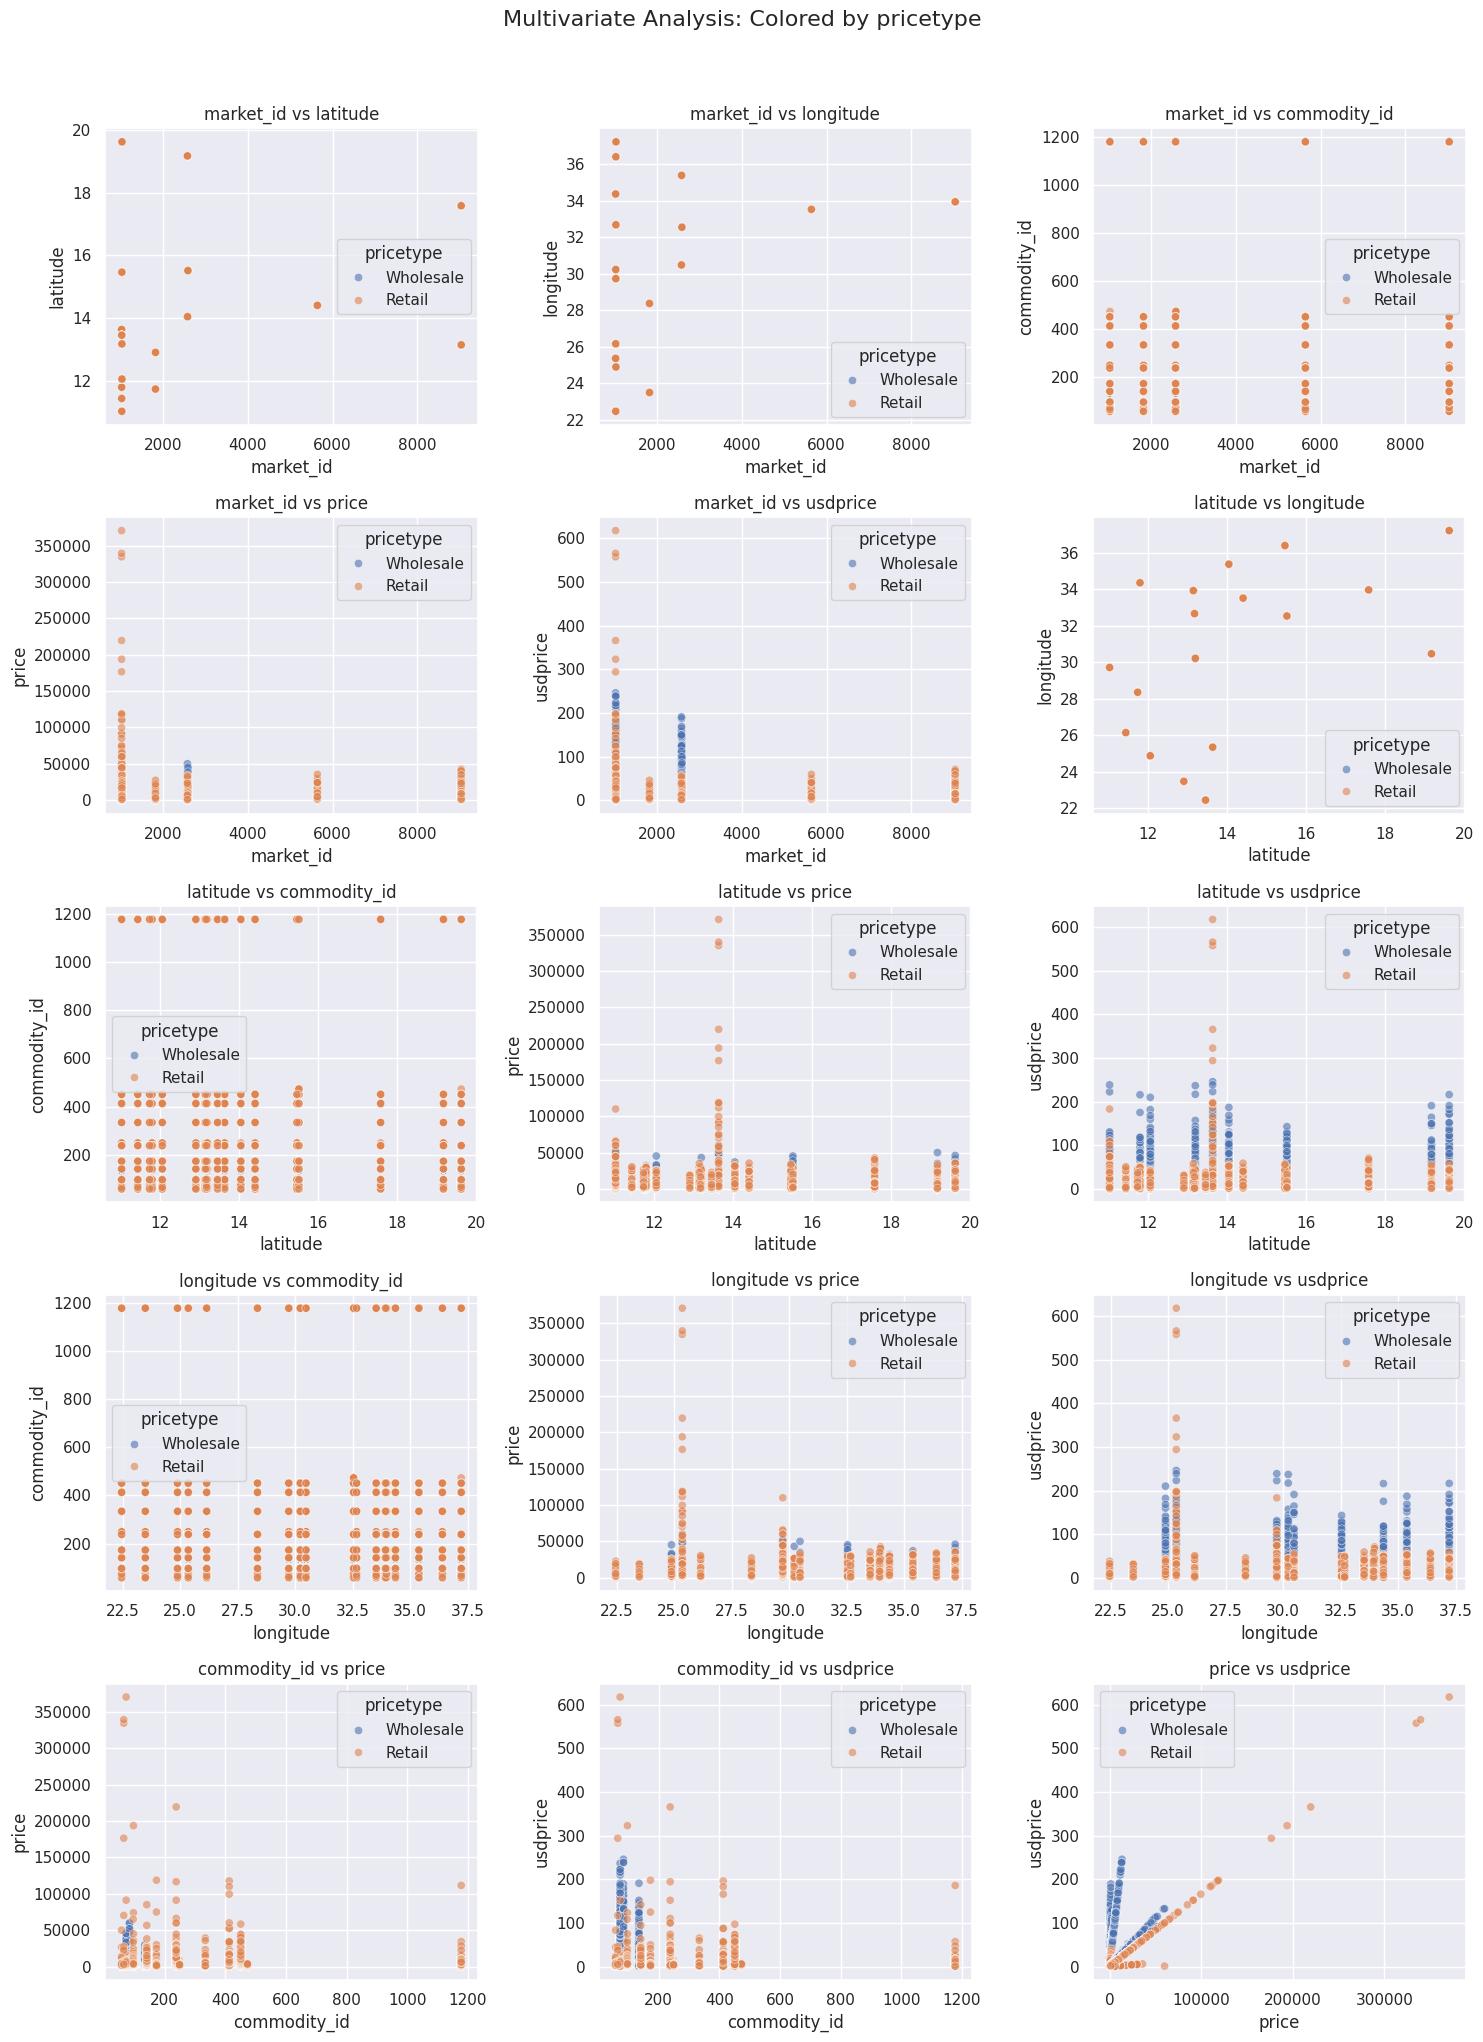


Analyzing relationships with Hue: currency...


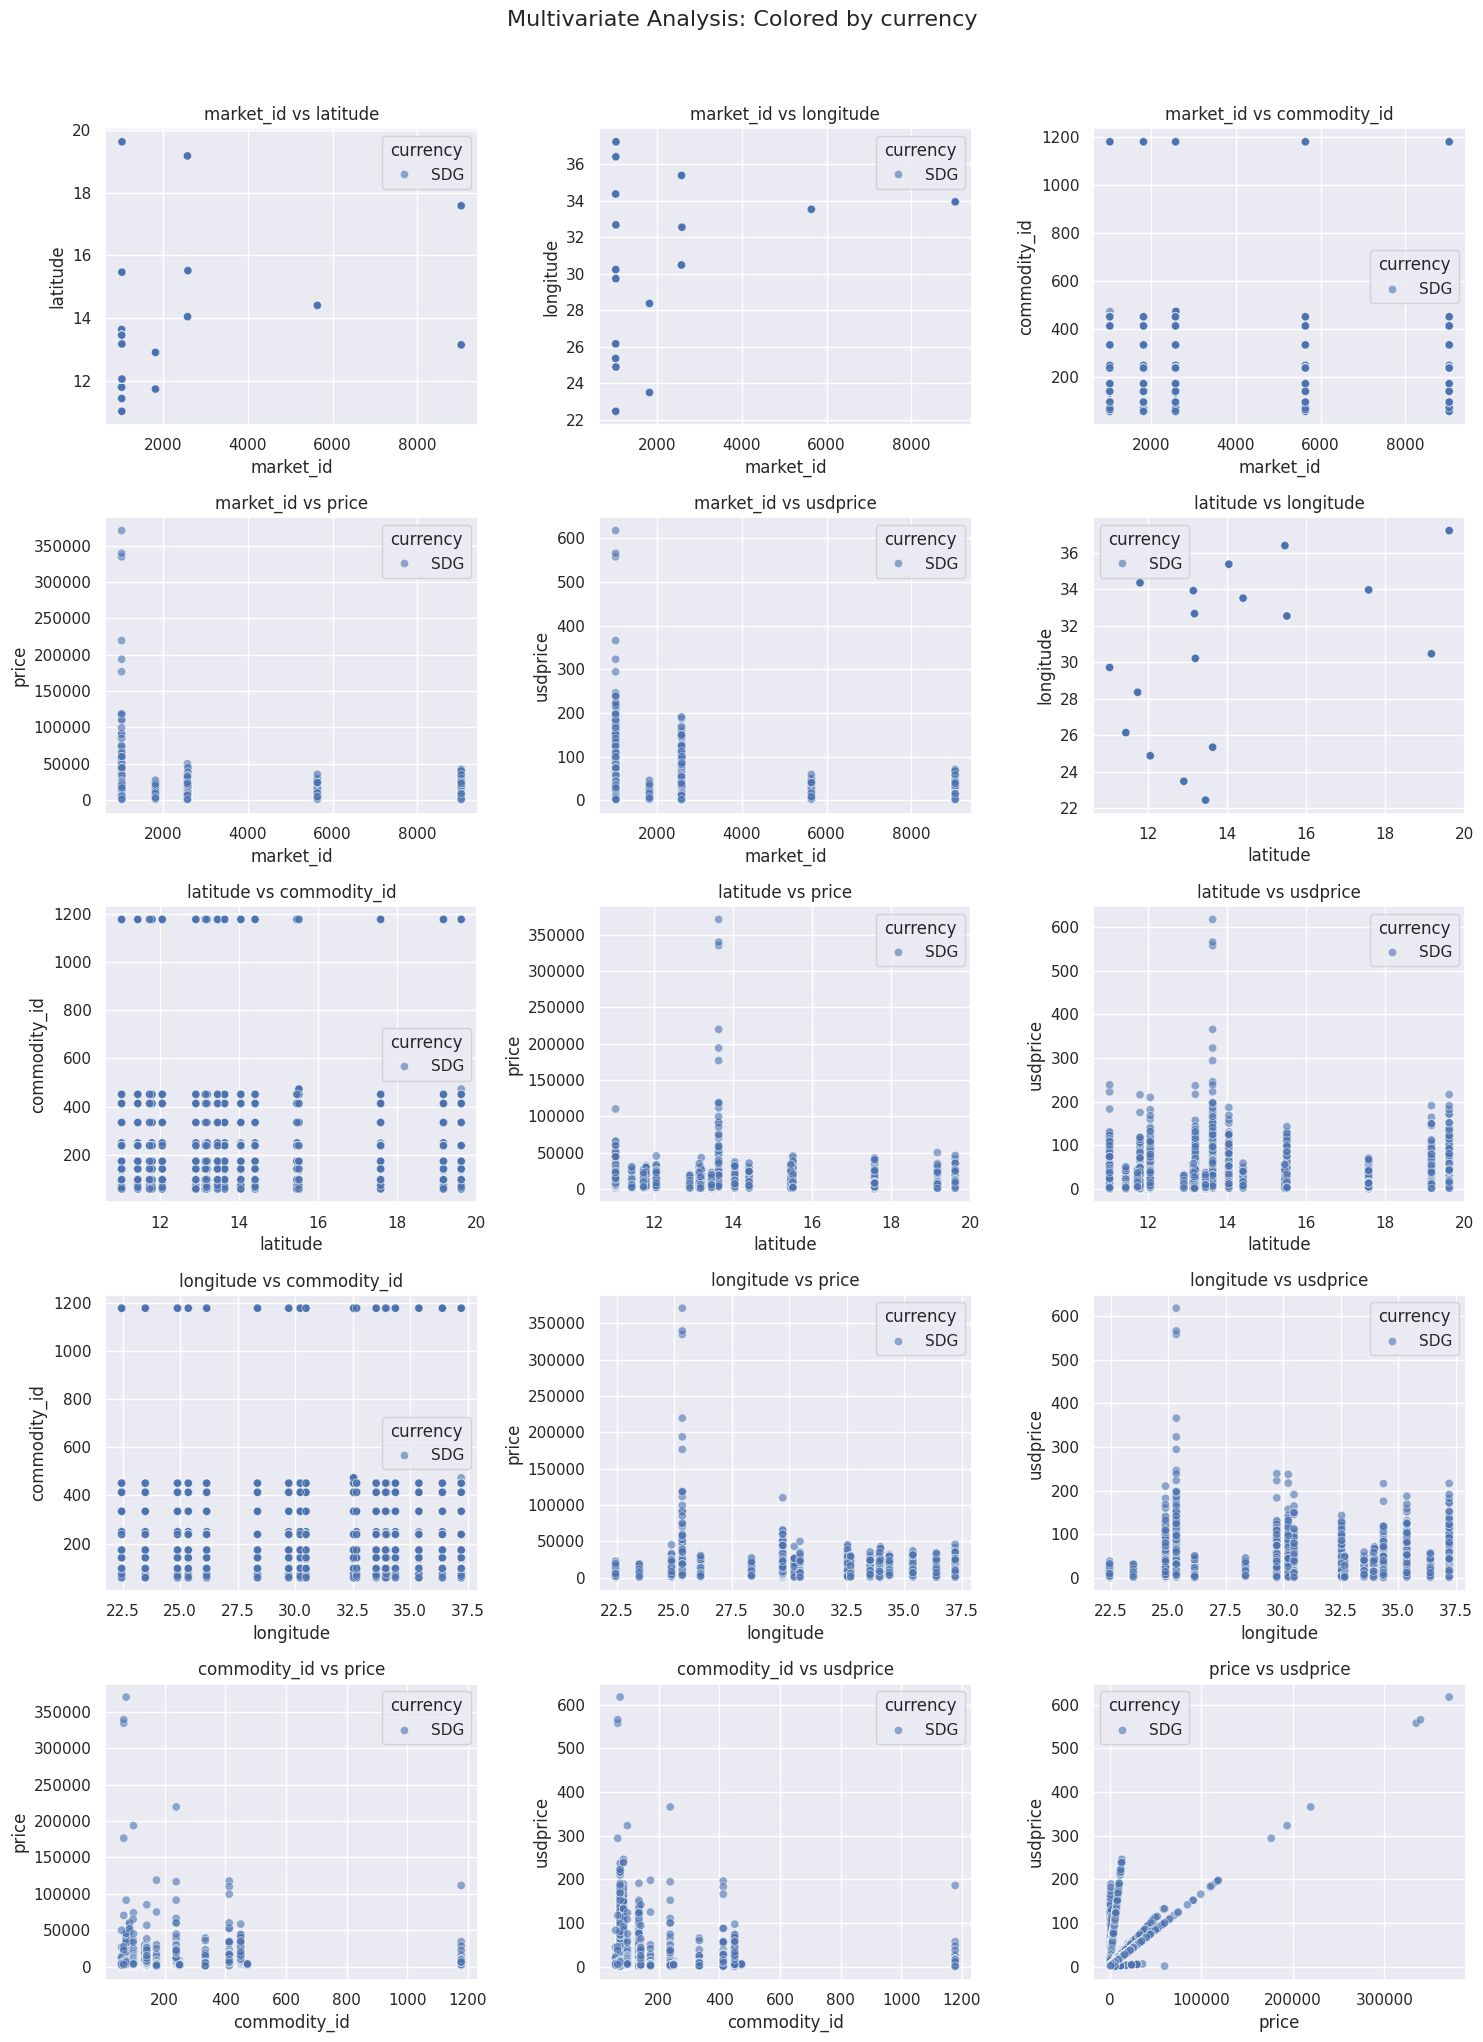

In [ ]:
import itertools
import math

# --- Multivariate Analysis: Numerical Pairs with Categorical Hue ---

# 1. Identifying valid columns
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Filtering categorical columns to those with few unique values for clear legends (e.g., < 10)
categorical_cols = [c for c in df.select_dtypes(include='object').columns if df[c].nunique() < 10]

# Generating pairs of numerical columns to plot
num_pairs = list(itertools.combinations(numerical_cols, 2))

if len(numerical_cols) > 1 and len(categorical_cols) > 0:
    # OUTER LOOP: Iterating through each categorical variable to use as the 'Hue'
    for cat_col in categorical_cols:
        print(f"\nAnalyzing relationships with Hue: {cat_col}...")

        # Defining grid size for the inner loop (numerical pairs)
        num_plots = len(num_pairs)
        num_cols_plot = 3
        num_rows_plot = math.ceil(num_plots / num_cols_plot)

        # Creating figure
        fig, axes = plt.subplots(num_rows_plot, num_cols_plot, figsize=(15, 4 * num_rows_plot))
        if num_plots > 1:
             axes = axes.flatten()
        else:
             axes = [axes]

        # INNER LOOP: Iterating through numerical pairs
        for i, (num1, num2) in enumerate(num_pairs):
            sns.scatterplot(data=df, x=num1, y=num2, hue=cat_col, ax=axes[i], alpha=0.6)
            axes[i].set_title(f'{num1} vs {num2}')

        # Hiding unused subplots
        for j in range(i + 1, len(axes)):
            axes[j].axis('off')

        plt.suptitle(f'Multivariate Analysis: Colored by {cat_col}', y=1.02, fontsize=16)
        plt.tight_layout()
        plt.show()
        print("="*80)
else:
    print("Not enough data for multivariate scatter analysis (need >1 numerical and >0 categorical columns).")

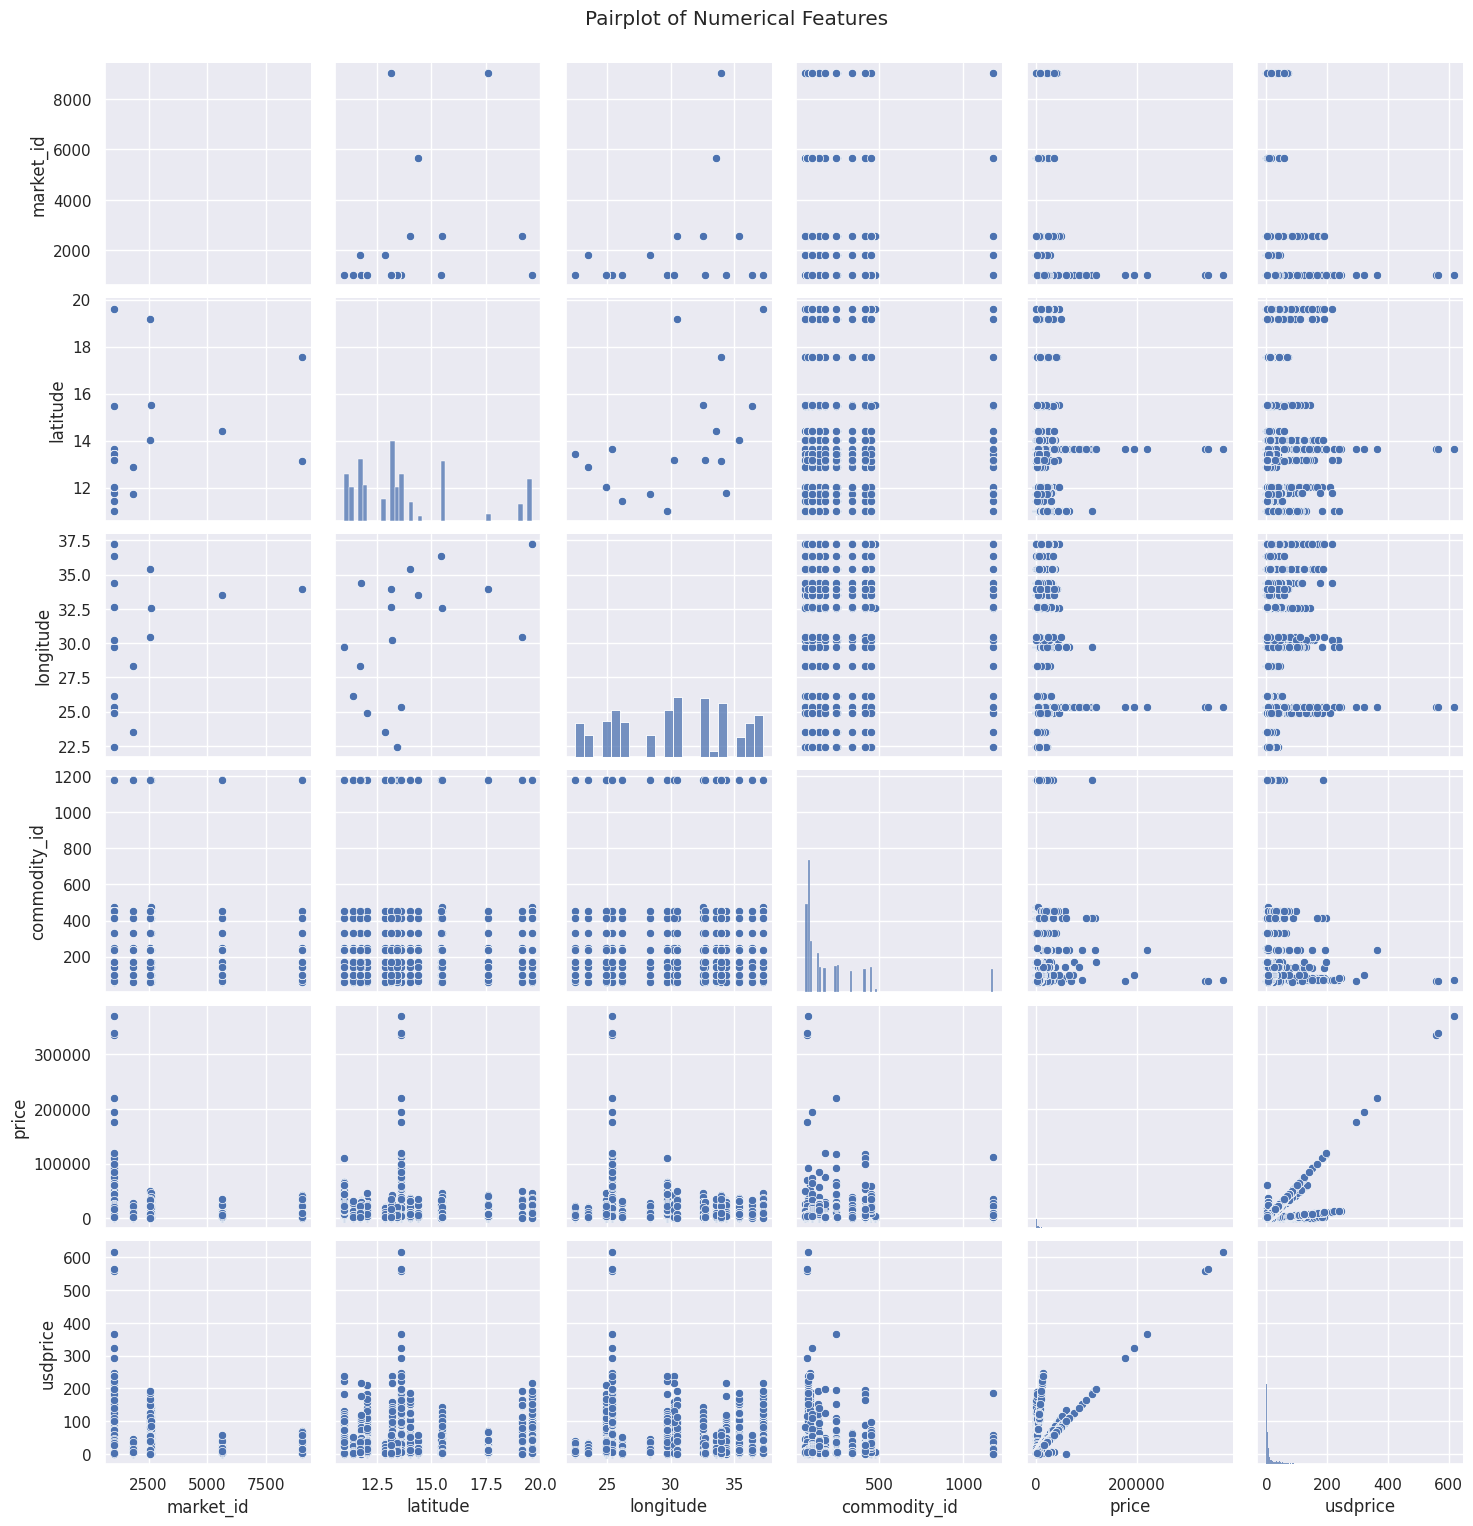

In [ ]:
sns.pairplot(df.select_dtypes(include = np.number))
plt.suptitle('Pairplot of Numerical Features', y=1.02)
plt.show()

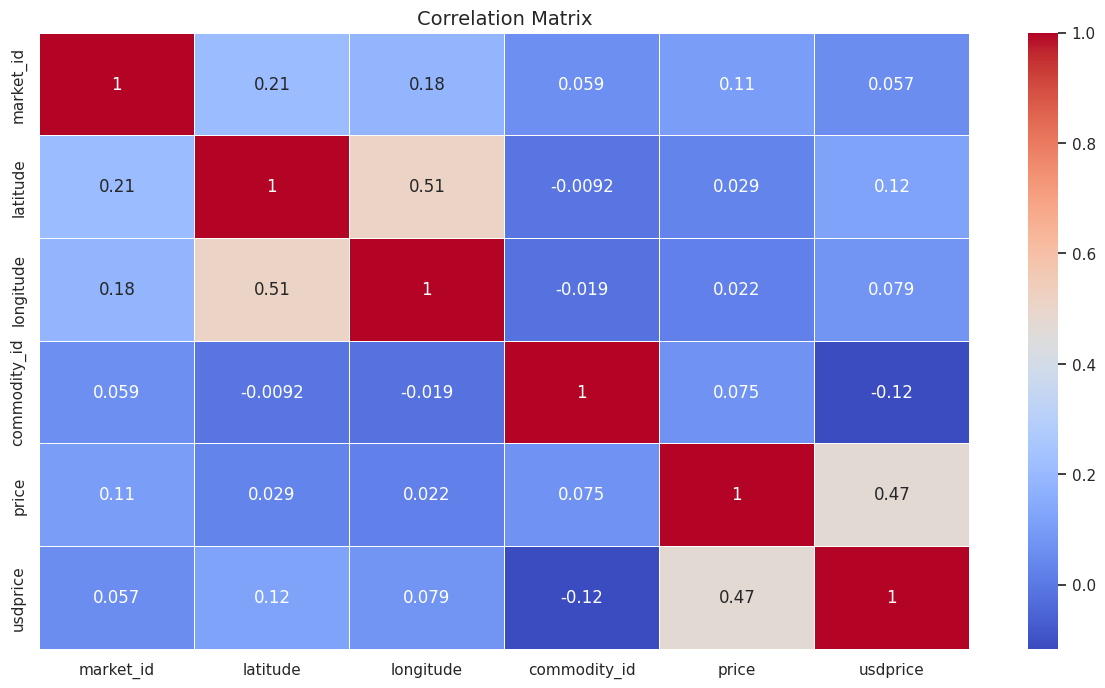

In [ ]:
plt.figure(figsize=(15, 8))
sns.heatmap(df.corr(numeric_only = True), annot=True, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix", fontsize=14)
plt.show()

# Statistical Analysis

## Humanitarian Feature Engineering & Macro-Diagnostics

--- 1. ENGINEERING THE HYPERINFLATION INDEX ---
✅ Engineered: Implicit Exchange Rate calculated across 14,638 market records.

--- 2. THE HYPERINFLATION DIVERGENCE (PEARSON CORRELATION) ---
Pearson Correlation (Local Price vs USD Price): 0.4695
P-Value: 0.0000e+00
 Insight: Severe Hyperinflationary Decoupling Detected.
   -> The local currency has fundamentally collapsed. Local food prices are exploding regardless of the underlying global USD value of the commodity.


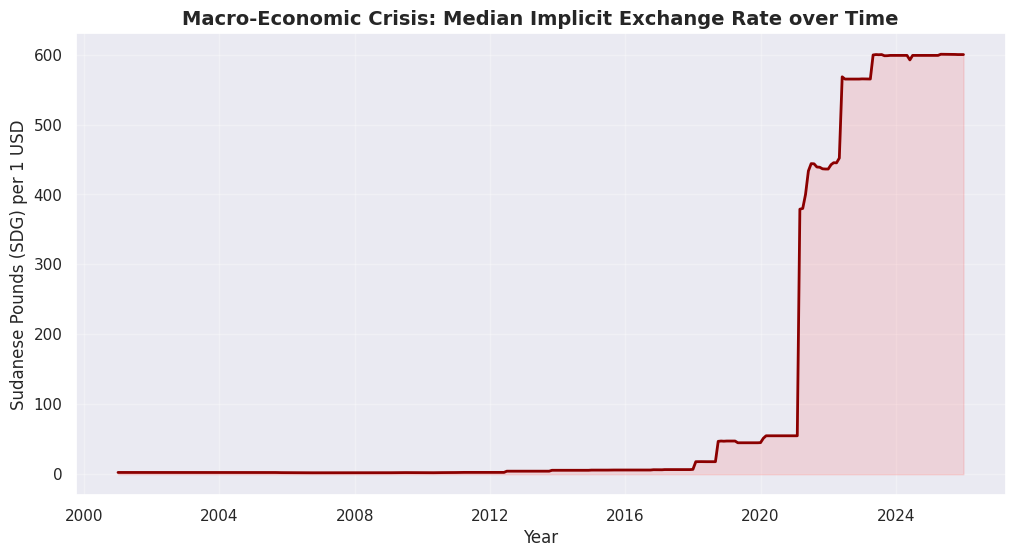


--- 3. SPATIAL INEQUITY & CONFLICT PREMIUMS (ONE-WAY ANOVA) ---
ANOVA P-Value (Geographic Price Inequity for Cereals): 0.0000e+00
 Insight: The variance in food prices between states is statistically significant.
   -> Spatial Arbitrage / Conflict Premium: Where you live in Sudan mathematically dictates your ability to afford basic survival calories.


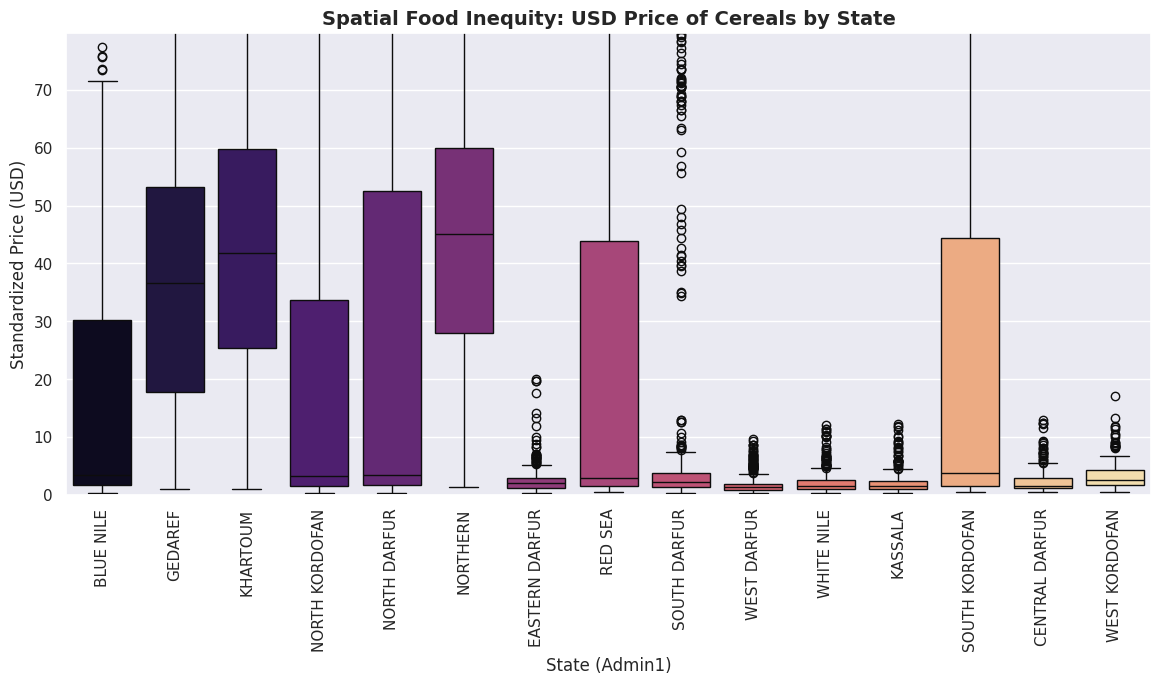


--- 4. COMMODITY SHOCK VOLATILITY (COEFFICIENT OF VARIATION) ---

 COMMODITY VOLATILITY INDEX (Most to Least Unstable):
                       Volatility_CV_%
CEREALS AND TUBERS          597.839482
MISCELLANEOUS FOOD          369.898732
VEGETABLES AND FRUITS       282.126840
PULSES AND NUTS             180.305619
MILK AND DAIRY              142.871151
OIL AND FATS                136.859954
MEAT, FISH AND EGGS         131.762485

   -> Interpretation: A higher CV % means the food category is highly susceptible to sudden, violent price shocks. A lower CV % implies stable, subsidized, or regulated pricing.


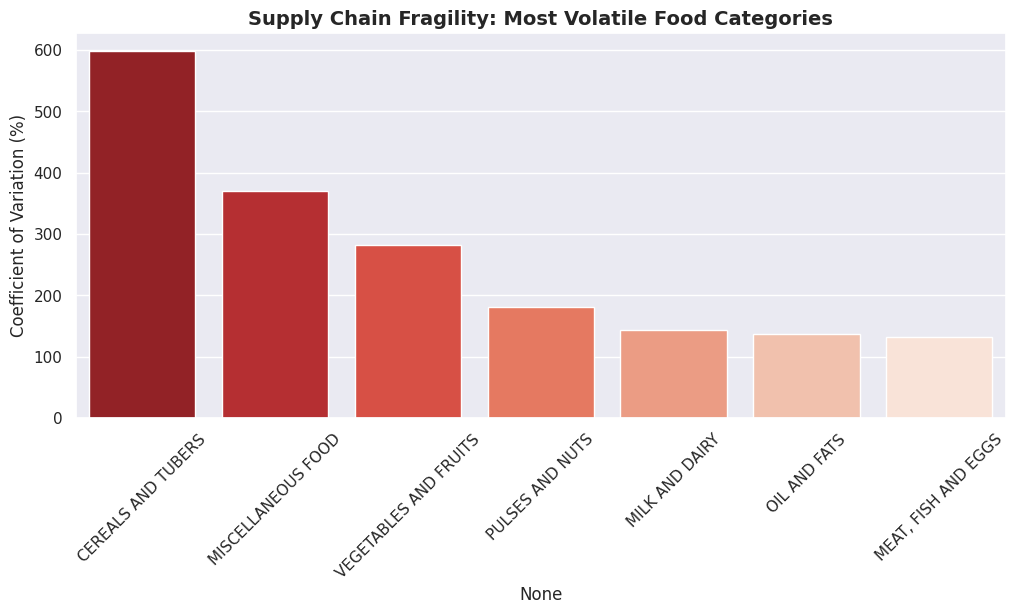

In [ ]:
import scipy.stats as stats

print("--- 1. ENGINEERING THE HYPERINFLATION INDEX ---")
# To understand the true cost of food, we must calculate the Implicit Exchange Rate
# (How many Sudanese Pounds does it take to equal the USD price of that exact commodity?)
# This reveals the true hyperinflationary collapse of purchasing power over time.

# Ensuring Date is datetime format
df['date'] = pd.to_datetime(df['date'])

# Calculate Implicit Exchange Rate (Avoid Division by Zero)
df_clean = df.dropna(subset=['price', 'usdprice', 'date']).copy()
df_clean = df_clean[df_clean['usdprice'] > 0] # Filter out missing/zero USD prices
df_clean['Implicit_Exchange_Rate'] = df_clean['price'] / df_clean['usdprice']

# Standardize text for analysis
df_clean['admin1'] = df_clean['admin1'].str.upper()
df_clean['category'] = df_clean['category'].str.upper()

print(f"✅ Engineered: Implicit Exchange Rate calculated across {len(df_clean):,} market records.")


# :::::: SOCIO-ECONOMIC HYPOTHESIS TESTING :::::::

print("\n--- 2. THE HYPERINFLATION DIVERGENCE (PEARSON CORRELATION) ---")
# In stable economies, local prices and USD prices move together. In hyperinflationary economies, they structurally decouple.

corr_coef, p_val_corr = stats.pearsonr(df_clean['price'], df_clean['usdprice'])

print(f"Pearson Correlation (Local Price vs USD Price): {corr_coef:.4f}")
print(f"P-Value: {p_val_corr:.4e}")

if p_val_corr < 0.05 and corr_coef < 0.5:
    print(" Insight: Severe Hyperinflationary Decoupling Detected.")
    print("   -> The local currency has fundamentally collapsed. Local food prices are exploding regardless of the underlying global USD value of the commodity.")
else:
    print(" Insight: The local currency retains a strong mathematical peg to global USD pricing.")

# Visualizing the Currency Collapse Over Time
monthly_rates = df_clean.groupby(df_clean['date'].dt.to_period('M'))['Implicit_Exchange_Rate'].median().reset_index()
monthly_rates['date'] = monthly_rates['date'].dt.to_timestamp()


plt.figure(figsize=(12, 6))
plt.plot(monthly_rates['date'], monthly_rates['Implicit_Exchange_Rate'], color='darkred', linewidth=2)
plt.title('Macro-Economic Crisis: Median Implicit Exchange Rate over Time', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Sudanese Pounds (SDG) per 1 USD')
plt.fill_between(monthly_rates['date'], monthly_rates['Implicit_Exchange_Rate'], 0, color='red', alpha=0.1)
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 3. SPATIAL INEQUITY & CONFLICT PREMIUMS (ONE-WAY ANOVA) ---")
# Food prices are mathematically distinct depending on the geographic state ('admin1').
# Conflict zones or supply-chain bottlenecks experience statistically higher localized pricing.

# We have to evaluate a specific staple commodity to prevent comparing Meat prices to Wheat prices
staple_food = df_clean[df_clean['category'].str.contains('CEREALS', na=False, case=False)]

if len(staple_food) > 0:
    states = staple_food['admin1'].unique()
    # Filtering to states with enough data for statistical validity
    valid_states = [s for s in states if len(staple_food[staple_food['admin1'] == s]) > 50]

    state_groups = [staple_food[staple_food['admin1'] == state]['usdprice'].dropna() for state in valid_states]

    f_stat, p_val_anova = stats.f_oneway(*state_groups)

    print(f"ANOVA P-Value (Geographic Price Inequity for Cereals): {p_val_anova:.4e}")
    if p_val_anova < 0.05:
        print(" Insight: The variance in food prices between states is statistically significant.")
        print("   -> Spatial Arbitrage / Conflict Premium: Where you live in Sudan mathematically dictates your ability to afford basic survival calories.")
    else:
        print(" Insight: Food prices are perfectly homogenized across all geographic borders.")

    # Visualizing the Spatial Inequity
    plt.figure(figsize=(14, 6))
    sns.boxplot(x='admin1', y='usdprice', data=staple_food[staple_food['admin1'].isin(valid_states)], palette='magma')
    plt.title('Spatial Food Inequity: USD Price of Cereals by State', fontsize=14, fontweight='bold')
    plt.xticks(rotation=90)
    plt.xlabel('State (Admin1)')
    plt.ylabel('Standardized Price (USD)')
    plt.ylim(0, staple_food['usdprice'].quantile(0.95))
    plt.show()


print("\n--- 4. COMMODITY SHOCK VOLATILITY (COEFFICIENT OF VARIATION) ---")
# Not all food categories suffer inflation equally.
# We calculate the Coefficient of Variation (CV = Standard Deviation / Mean) to measure relative shock volatility.

cv_results = {}
for category in df_clean['category'].unique():
    subset = df_clean[df_clean['category'] == category]['price'].dropna()
    if len(subset) > 100:
        cv = (subset.std() / subset.mean()) * 100
        cv_results[category] = cv

# Converting to DataFrame and sort
cv_df = pd.DataFrame.from_dict(cv_results, orient='index', columns=['Volatility_CV_%']).sort_values(by='Volatility_CV_%', ascending=False)

print("\n COMMODITY VOLATILITY INDEX (Most to Least Unstable):")
print(cv_df.head(10))
print("\n   -> Interpretation: A higher CV % means the food category is highly susceptible to sudden, violent price shocks. A lower CV % implies stable, subsidized, or regulated pricing.")


plt.figure(figsize=(12, 5))
sns.barplot(x=cv_df.index[:10], y=cv_df['Volatility_CV_%'][:10], palette='Reds_r')
plt.title('Supply Chain Fragility: Most Volatile Food Categories', fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel('Coefficient of Variation (%)')
plt.show()

## Advanced Humanitarian Econometrics & Causality

--- 1. THE 'LEAN SEASON' DIAGNOSTIC (KRUSKAL-WALLIS H-TEST) ---
Kruskal-Wallis P-Value (Seasonal Variance): 1.6451e-02
 Insight: Statistically significant Seasonality detected.
 -> The 'Lean Season' is mathematically real. Prices reliably surge and collapse based on the harvest calendar, requiring pre-emptive humanitarian food stockpiling.


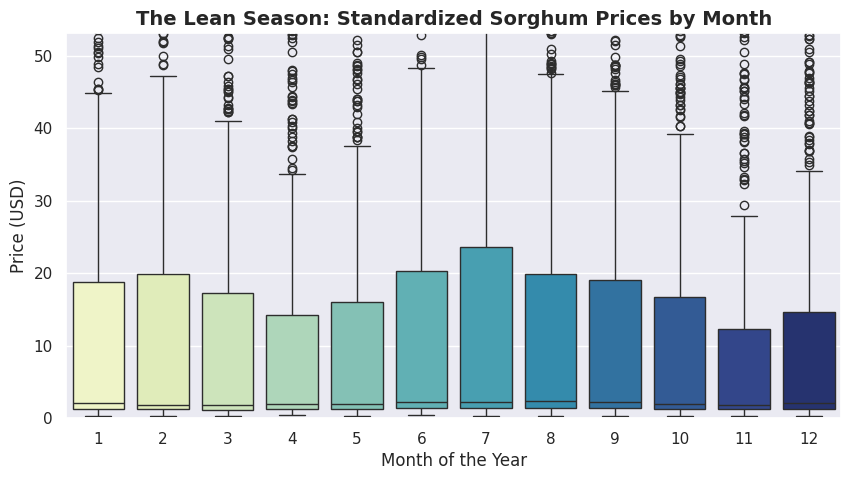


--- 2. STRUCTURAL REGIME BREAKS (WELCH'S T-TEST) ---
Welch's T-Test P-Value (Regime Break): 0.0000e+00
 Insight: A catastrophic Structural Regime Break is confirmed.
   -> Pre-2019 Avg Exchange Rate: 5.22 SDG/USD
   -> Post-2019 Avg Exchange Rate: 431.91 SDG/USD
   -> The mathematical laws governing this economy were fundamentally rewritten post-2019.

--- 3. SPATIAL PRICE TRANSMISSION (GRANGER CAUSALITY) ---

Testing if Khartoum Prices Granger-Cause Darfur Prices (Up to 3 months lag):
 Insight: Null Hypothesis accepted. Markets are isolated. A shock in Khartoum does NOT predict a shock in Darfur.
 -> This implies severe supply-chain fragmentation (roads are likely blocked or unsafe).


In [ ]:
import scipy.stats as stats
from statsmodels.tsa.stattools import grangercausalitytests

print("--- 1. THE 'LEAN SEASON' DIAGNOSTIC (KRUSKAL-WALLIS H-TEST) ---")
# Staple food prices (like Sorghum) are not random; they follow a strict
# agricultural calendar, spiking just before the harvest (The Lean Season).
# We use a non-parametric test because price data is highly skewed by inflation.

# Isolate a critical survival calorie: Sorghum (the primary staple in Sudan)
sorghum_df = df_clean[df_clean['commodity'].str.contains('Sorghum', case=False, na=False)].copy()

if len(sorghum_df) > 0:
    # Extracting the month
    sorghum_df['Month'] = sorghum_df['date'].dt.month

    # Grouping USD prices by month
    monthly_groups = [sorghum_df[sorghum_df['Month'] == m]['usdprice'].dropna() for m in range(1, 13)]

    h_stat, p_val_kw = stats.kruskal(*monthly_groups)

    print(f"Kruskal-Wallis P-Value (Seasonal Variance): {p_val_kw:.4e}")
    if p_val_kw < 0.05:
        print(" Insight: Statistically significant Seasonality detected.")
        print(" -> The 'Lean Season' is mathematically real. Prices reliably surge and collapse based on the harvest calendar, requiring pre-emptive humanitarian food stockpiling.")
    else:
        print(" Insight: Prices do not fluctuate based on the month. Inflation has destroyed normal agricultural seasonality.")

    # Visualizing the Agricultural Cycle
    plt.figure(figsize=(10, 5))
    sns.boxplot(x='Month', y='usdprice', data=sorghum_df, palette='YlGnBu')
    plt.title('The Lean Season: Standardized Sorghum Prices by Month', fontsize=14, fontweight='bold')
    plt.xlabel('Month of the Year')
    plt.ylabel('Price (USD)')
    plt.ylim(0, sorghum_df['usdprice'].quantile(0.95))
    plt.show()


print("\n--- 2. STRUCTURAL REGIME BREAKS (WELCH'S T-TEST) ---")
# The political revolution and economic collapse of 2018/2019 caused a
# permanent, structural break in the purchasing power of the population.

# Defining Pre-Crisis (Before 2019) and Post-Crisis (2019 Onward)
pre_crisis = df_clean[df_clean['date'].dt.year < 2019]['Implicit_Exchange_Rate'].dropna()
post_crisis = df_clean[df_clean['date'].dt.year >= 2019]['Implicit_Exchange_Rate'].dropna()

# We use Welch's T-Test because the variance in the post-crisis era will be exponentially higher
t_stat_break, p_val_break = stats.ttest_ind(pre_crisis, post_crisis, equal_var=False)

print(f"Welch's T-Test P-Value (Regime Break): {p_val_break:.4e}")
if p_val_break < 0.05:
    print(" Insight: A catastrophic Structural Regime Break is confirmed.")
    print(f"   -> Pre-2019 Avg Exchange Rate: {pre_crisis.mean():.2f} SDG/USD")
    print(f"   -> Post-2019 Avg Exchange Rate: {post_crisis.mean():.2f} SDG/USD")
    print("   -> The mathematical laws governing this economy were fundamentally rewritten post-2019.")


print("\n--- 3. SPATIAL PRICE TRANSMISSION (GRANGER CAUSALITY) ---")
# Do price shocks in the central hub (Khartoum) CAUSE price shocks
# in peripheral regions (like Darfur) weeks later?
# We test if the time-series of Khartoum's prices can predict Darfur's prices.

if 'admin1' in df_clean.columns:

    # Filtering for Sorghum in two distinct regions
    khartoum = sorghum_df[sorghum_df['admin1'].str.contains('KHARTOUM', na=False)]
    darfur = sorghum_df[sorghum_df['admin1'].str.contains('DARFUR', na=False)]

    if len(khartoum) > 0 and len(darfur) > 0:
        # Resampling to monthly averages to align the time-series mathematically
        k_ts = khartoum.resample('M', on='date')['price'].mean().rename('Khartoum_Price')
        d_ts = darfur.resample('M', on='date')['price'].mean().rename('Darfur_Price')

        # Merging and drop missing months
        transmission_df = pd.concat([d_ts, k_ts], axis=1).dropna()

        if len(transmission_df) > 20:
            print("\nTesting if Khartoum Prices Granger-Cause Darfur Prices (Up to 3 months lag):")

            # The test here checks if Past Khartoum prices help predict Current Darfur prices
            gc_results = grangercausalitytests(transmission_df[['Darfur_Price', 'Khartoum_Price']], maxlag=3, verbose=False)

            # Checking the p-value at Lag 1 (1 month delay)
            p_val_gc = gc_results[1][0]['ssr_ftest'][1]
            if p_val_gc < 0.05:
                print(" Insight: Positive Granger Causality Detected (P-Value < 0.05).")
                print("   -> Market Integration: A food price shock in Khartoum mathematically ripples into Darfur with a 1-month delay.")
            else:
                print(" Insight: Null Hypothesis accepted. Markets are isolated. A shock in Khartoum does NOT predict a shock in Darfur.")
                print(" -> This implies severe supply-chain fragmentation (roads are likely blocked or unsafe).")

# Time-Series Analysis

--- 1. TIME-SERIES PREPARATION & TREND SMOOTHING ---


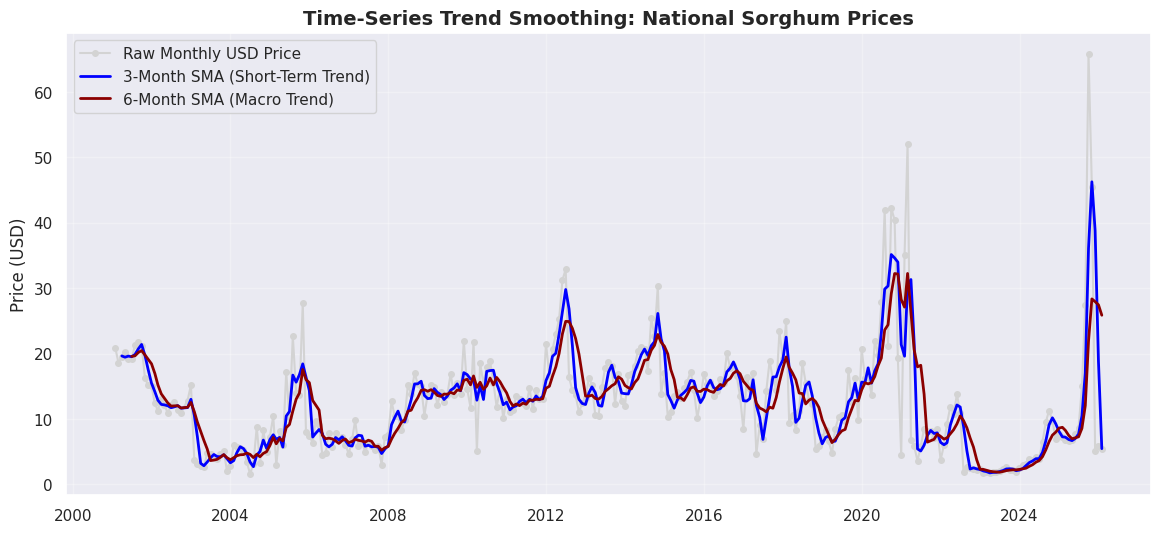


--- 2. SEASONAL DECOMPOSITION (TREND VS. HARVEST VS. CRISIS) ---


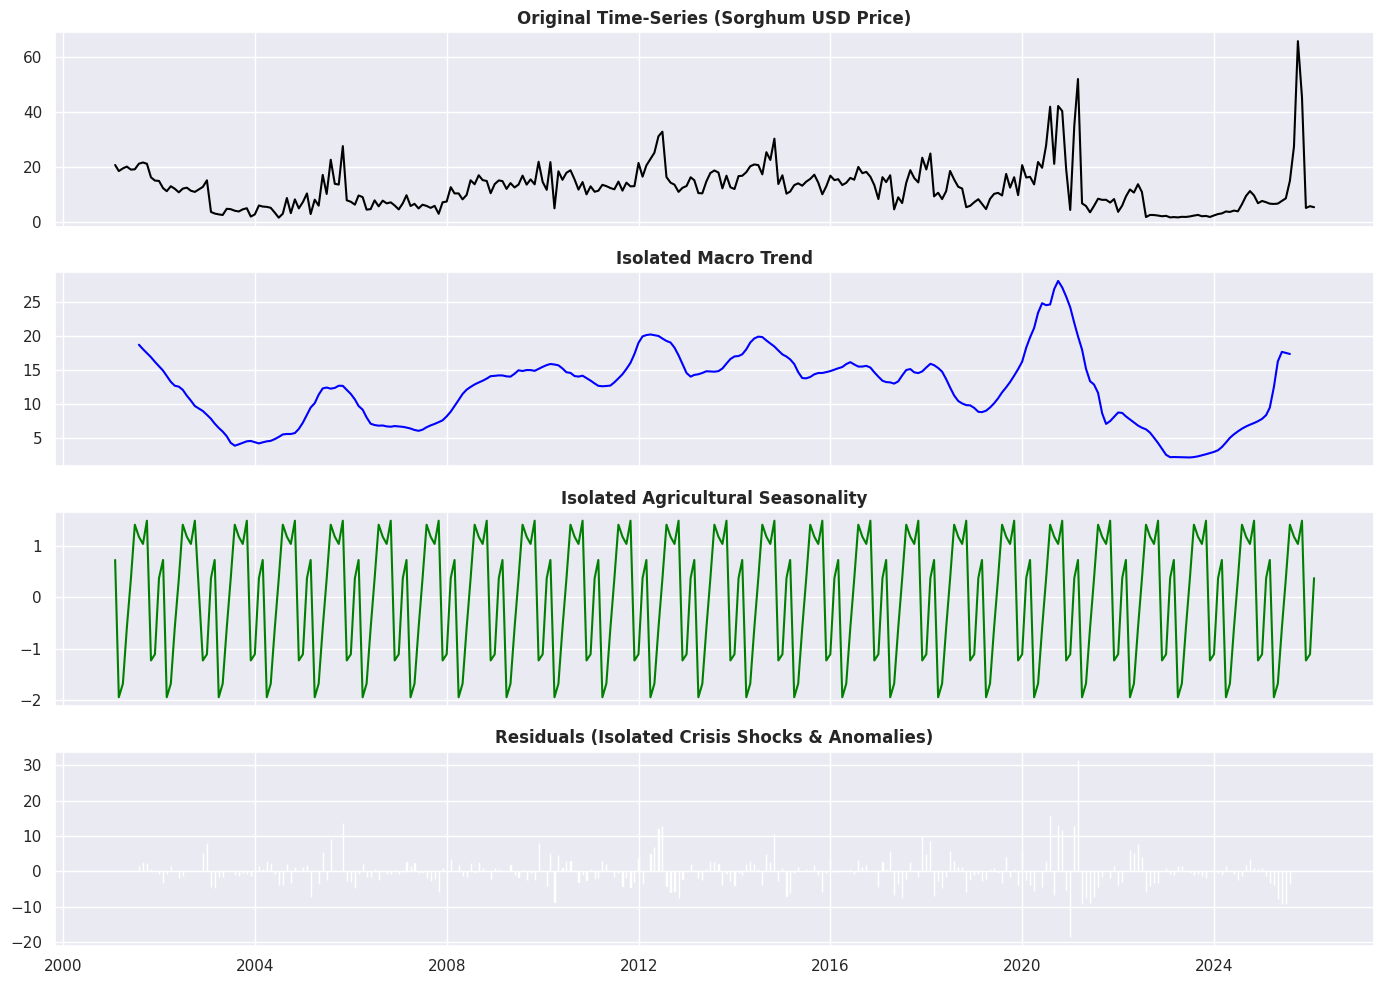


--- 3. MARKET MEMORY (AUTOCORRELATION) ---


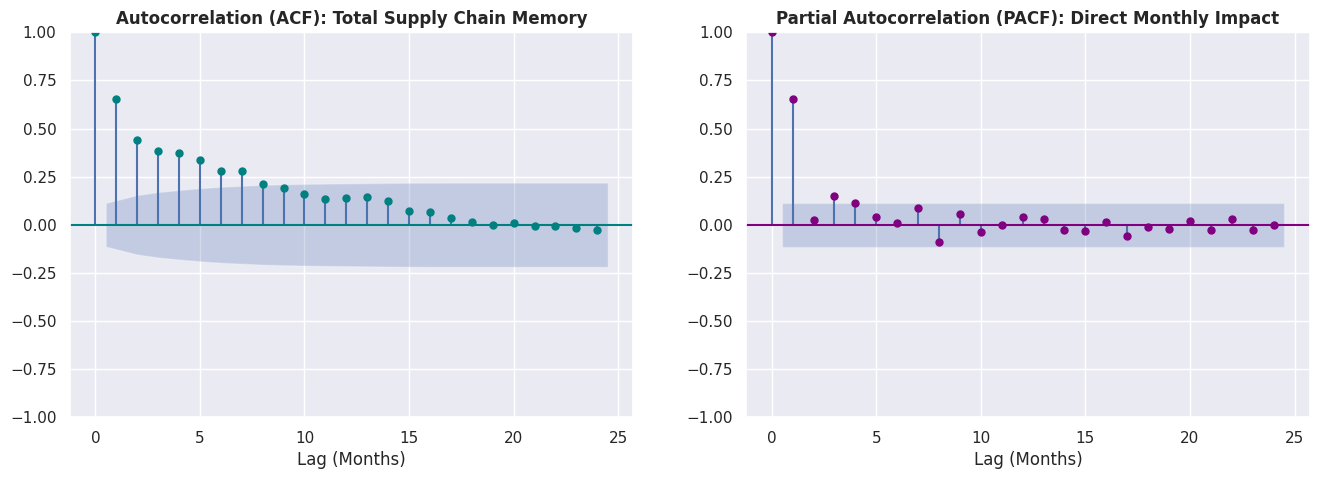


--- 4. ALGORITHMIC ANOMALY DETECTION (ROLLING Z-SCORES) ---
 DETECTED PRICE ANOMALIES (CRISIS SHOCKS):
 -> No extreme statistical anomalies detected in this specific series.


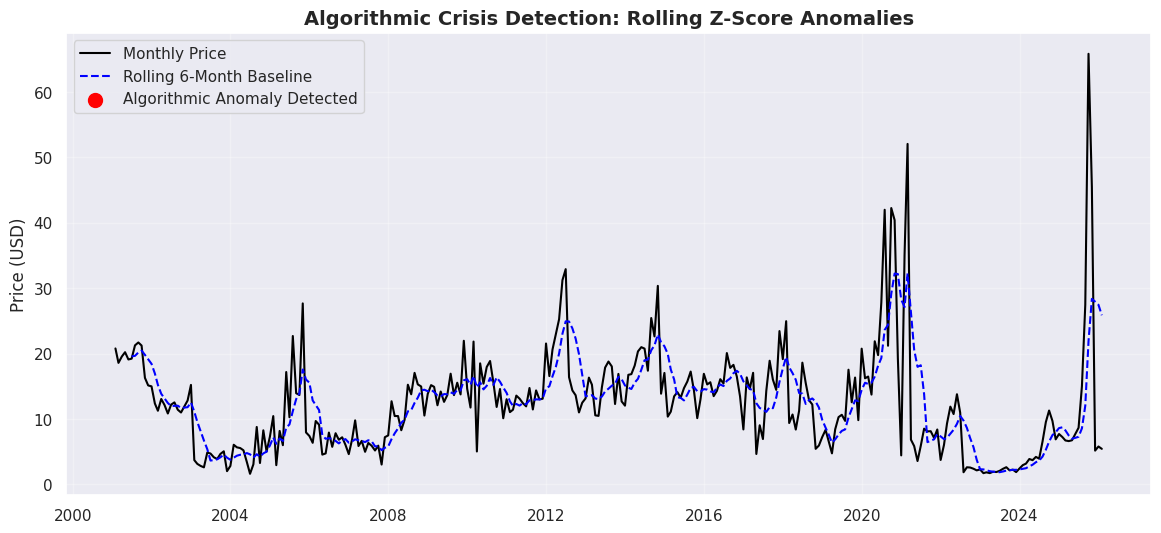

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

print("--- 1. TIME-SERIES PREPARATION & TREND SMOOTHING ---")
# To run clean time-series math, we need a continuous, evenly spaced dataset.
# We will create a National Average Monthly Price Index for Sorghum (the primary staple).

# Filtering for Sorghum and calculate the monthly national average USD price
ts_df = df_clean[df_clean['commodity'].str.contains('Sorghum', case=False, na=False)].copy()
ts_df = ts_df.set_index('date').resample('M')['usdprice'].mean().dropna().to_frame()

# Calculating 3-Month and 6-Month Simple Moving Averages (SMA)
ts_df['SM_3M'] = ts_df['usdprice'].rolling(window=3).mean()
ts_df['SMA_6M'] = ts_df['usdprice'].rolling(window=6).mean()

plt.figure(figsize=(14, 6))
plt.plot(ts_df.index, ts_df['usdprice'], color='lightgray', label='Raw Monthly USD Price', marker='o', markersize=4)
plt.plot(ts_df.index, ts_df['SM_3M'], color='blue', linewidth=2, label='3-Month SMA (Short-Term Trend)')
plt.plot(ts_df.index, ts_df['SMA_6M'], color='darkred', linewidth=2, label='6-Month SMA (Macro Trend)')
plt.title('Time-Series Trend Smoothing: National Sorghum Prices', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 2. SEASONAL DECOMPOSITION (TREND VS. HARVEST VS. CRISIS) ---")
# We mathematically rip the time-series apart into 3 vectors:
# 1. Trend: The underlying hyperinflation/macro direction.
# 2. Seasonal: The recurring agricultural harvest cycle.
# 3. Residual: The unexplained noise (which in humanitarian data = sudden conflict shocks).

# Using an additive model
decomposition = seasonal_decompose(ts_df['usdprice'], model='additive', period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
axes[0].plot(ts_df.index, ts_df['usdprice'], color='black')
axes[0].set_title('Original Time-Series (Sorghum USD Price)', fontweight='bold')

axes[1].plot(ts_df.index, decomposition.trend, color='blue')
axes[1].set_title('Isolated Macro Trend', fontweight='bold')

axes[2].plot(ts_df.index, decomposition.seasonal, color='green')
axes[2].set_title('Isolated Agricultural Seasonality', fontweight='bold')

axes[3].bar(ts_df.index, decomposition.resid, color='red')
axes[3].set_title('Residuals (Isolated Crisis Shocks & Anomalies)', fontweight='bold')

plt.tight_layout()
plt.show()


print("\n--- 3. MARKET MEMORY (AUTOCORRELATION) ---")
# Does a price shock in January dictate the price in February? What about June?
# ACF and PACF prove how long the "memory" of a price spike lasts in the supply chain.

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
plot_acf(ts_df['usdprice'].dropna(), lags=24, ax=ax1, color='teal', alpha=0.05)
ax1.set_title('Autocorrelation (ACF): Total Supply Chain Memory', fontweight='bold')
ax1.set_xlabel('Lag (Months)')

plot_pacf(ts_df['usdprice'].dropna(), lags=24, ax=ax2, color='purple', alpha=0.05)
ax2.set_title('Partial Autocorrelation (PACF): Direct Monthly Impact', fontweight='bold')
ax2.set_xlabel('Lag (Months)')
plt.show()


print("\n--- 4. ALGORITHMIC ANOMALY DETECTION (ROLLING Z-SCORES) ---")
# We want to mathematically flag specific months where the price spiked so hard
# it violated standard deviation thresholds (A "Black Swan" food crisis event).

# Calculate the rolling 6-month mean and standard deviation
ts_df['Rolling_Mean'] = ts_df['usdprice'].rolling(window=6).mean()
ts_df['Rolling_Std'] = ts_df['usdprice'].rolling(window=6).std()

# Calculating the Z-Score: How many standard deviations is the current price from the recent norm?
ts_df['Z_Score'] = (ts_df['usdprice'] - ts_df['Rolling_Mean']) / ts_df['Rolling_Std']

# Defining an Anomaly as any month where the price is > 2.5 standard deviations above the recent norm
ts_df['Is_Anomaly'] = np.where(ts_df['Z_Score'] > 2.5, ts_df['usdprice'], np.nan)

print(" DETECTED PRICE ANOMALIES (CRISIS SHOCKS):")
anomalies = ts_df[ts_df['Z_Score'] > 2.5]
if len(anomalies) > 0:
    for index, row in anomalies.iterrows():
        print(f"   -> {index.strftime('%B %Y')}: Price hit ${row['usdprice']:.2f} (Z-Score: {row['Z_Score']:.2f})")
else:
    print(" -> No extreme statistical anomalies detected in this specific series.")

plt.figure(figsize=(14, 6))
plt.plot(ts_df.index, ts_df['usdprice'], color='black', label='Monthly Price', zorder=1)
plt.plot(ts_df.index, ts_df['Rolling_Mean'], color='blue', linestyle='--', label='Rolling 6-Month Baseline', zorder=2)
plt.scatter(ts_df.index, ts_df['Is_Anomaly'], color='red', s=100, label='Algorithmic Anomaly Detected', zorder=3)
plt.title('Algorithmic Crisis Detection: Rolling Z-Score Anomalies', fontsize=14, fontweight='bold')
plt.ylabel('Price (USD)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Feature Engineering Spatio-Temporal

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

print("--- 1. CYCLICAL TEMPORAL ENCODING ---")
# We are using Sine and Cosine transformations to map the months onto a continuous 2D circle.

df_clean['Month'] = df_clean['date'].dt.month
df_clean['Year'] = df_clean['date'].dt.year

df_clean['Month_Sin'] = np.sin(2 * np.pi * df_clean['Month'] / 12.0)
df_clean['Month_Cos'] = np.cos(2 * np.pi * df_clean['Month'] / 12.0)

print(" Engineered: Cyclical Sine/Cosine Temporal Embeddings.")


print("\n--- 2. GEOSPATIAL META-CLUSTERING ---")
# GPS coordinates (Latitude/Longitude) are raw numbers. We use K-Means to cluster
# physical markets together, creating 'Supply Chain Hubs'.

# Dropping missing coordinates
ml_df = df_clean.dropna(subset=['latitude', 'longitude']).copy()

# Initializing K-Means to find 8 distinct geographic hubs
kmeans_geo = KMeans(n_clusters=8, random_state=42, n_init=10)
ml_df['Geospatial_Hub_ID'] = kmeans_geo.fit_predict(ml_df[['latitude', 'longitude']])

# One-Hot Encode the Hubs to prevent the algorithm from thinking Hub 8 is "greater" than Hub 1
hub_dummies = pd.get_dummies(ml_df['Geospatial_Hub_ID'], prefix='GeoHub', drop_first=True)
ml_df = pd.concat([ml_df, hub_dummies], axis=1)

print(" Engineered: Latitude/Longitude condensed into Unsupervised Geospatial Hubs.")


print("\n--- 3. AUTOREGRESSIVE COMMODITY LAGS ---")
# We must give the algorithm "Memory". What did THIS specific commodity cost in THIS specific market last month?
# We must sort by Market, Commodity, and Date, then apply a shifted lag.

ml_df = ml_df.sort_values(by=['market_id', 'commodity_id', 'date']).reset_index(drop=True)

# Group by Market and Commodity, then shift the USD price by 1 and 2 periods (months)
ml_df['USD_Price_Lag_1'] = ml_df.groupby(['market_id', 'commodity_id'])['usdprice'].shift(1)
ml_df['USD_Price_Lag_2'] = ml_df.groupby(['market_id', 'commodity_id'])['usdprice'].shift(2)

# Calculate the localized momentum (Rate of Change over the last month)
ml_df['Price_Momentum_%'] = ((ml_df['usdprice'] - ml_df['USD_Price_Lag_1']) / ml_df['USD_Price_Lag_1']) * 100

print(" Engineered: Autoregressive Sliding Windows & Price Momentum.")


print("\n--- 4. SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---")
# One-Hot Encoding 50 different commodities and 100 markets will explode the matrix.
# We are replacing the text string (e.g., 'Sorghum') with its historical average USD price.

global_mean_usd = ml_df['usdprice'].mean()
smoothing_weight = 10

def smoothed_target_encode(df, category_col, target_col, weight, global_mean):
    agg = df.groupby(category_col)[target_col].agg(['count', 'mean'])
    counts = agg['count']
    means = agg['mean']
    smoothed_means = (counts * means + weight * global_mean) / (counts + weight)
    return df[category_col].map(smoothed_means)

ml_df['Commodity_Encoded'] = smoothed_target_encode(ml_df, 'commodity', 'usdprice', smoothing_weight, global_mean_usd)
ml_df['Market_Encoded'] = smoothed_target_encode(ml_df, 'market', 'usdprice', smoothing_weight, global_mean_usd)

print(" Engineered: Bayesian Smoothed Target Encoding for Commodities and Markets.")


print("\n--- 5. MATRIX SANITIZATION & TARGET DEFINITION ---")
# Defining the continuous Target Variable (We are predicting the current month's USD Price)
# based on the historical lags, geography, and commodity type.

# Dropping NaNs created by the shifting/lagging process
final_features = [
    'Year', 'Month_Sin', 'Month_Cos',
    'Commodity_Encoded', 'Market_Encoded',
    'USD_Price_Lag_1', 'USD_Price_Lag_2', 'Price_Momentum_%'
] + list(hub_dummies.columns)

ml_df_final = ml_df.dropna(subset=final_features + ['usdprice']).copy()

# Standarding the continuous feature variance
scaler = StandardScaler()
X = ml_df_final[final_features].copy()
continuous_cols = ['Commodity_Encoded', 'Market_Encoded', 'USD_Price_Lag_1', 'USD_Price_Lag_2', 'Price_Momentum_%']
X[continuous_cols] = scaler.fit_transform(X[continuous_cols])

y = ml_df_final['usdprice'].copy()

print(f" Feature Matrix Assembly Complete. {len(X):,} viable temporal records ready for Machine Learning.")
print("\n Final Machine-Readable Matrix (X) Preview:")
print(X.head(3))

--- 1. CYCLICAL TEMPORAL ENCODING ---
 Engineered: Cyclical Sine/Cosine Temporal Embeddings.

--- 2. GEOSPATIAL META-CLUSTERING ---
 Engineered: Latitude/Longitude condensed into Unsupervised Geospatial Hubs.

--- 3. AUTOREGRESSIVE COMMODITY LAGS ---
 Engineered: Autoregressive Sliding Windows & Price Momentum.

--- 4. SMOOTHED TARGET ENCODING (HIGH-CARDINALITY) ---
 Engineered: Bayesian Smoothed Target Encoding for Commodities and Markets.

--- 5. MATRIX SANITIZATION & TARGET DEFINITION ---
 Feature Matrix Assembly Complete. 14,136 viable temporal records ready for Machine Learning.

 Final Machine-Readable Matrix (X) Preview:
   Year     Month_Sin  Month_Cos  Commodity_Encoded  Market_Encoded  \
2  2021  8.660254e-01  -0.500000          -0.867443        1.094936   
3  2021  5.000000e-01  -0.866025          -0.867443        1.094936   
4  2021  1.224647e-16  -1.000000          -0.867443        1.094936   

   USD_Price_Lag_1  USD_Price_Lag_2  Price_Momentum_%  GeoHub_1  GeoHub_2  \
2 

--- 1. CHRONOLOGICAL DATA SPLITTING ---
 Training Set: 11,308 records (Historical Data)
 Testing Set: 2,828 records (Future/Out-of-Sample)

--- 2. ALGORITHMIC TRAINING (EARLY WARNING SYSTEM) ---
 Both Regression Architectures successfully trained on historical crisis data.

--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---
 Random Forest Performance:
   -> Mean Absolute Error (MAE): $1.93 USD
   -> Root Mean Squared Error (RMSE): $4.26 USD
   -> R-Squared (R2): 0.9729
----------------------------------------
 XGBoost Performance:
   -> Mean Absolute Error (MAE): $1.30 USD
   -> Root Mean Squared Error (RMSE): $3.77 USD
   -> R-Squared (R2): 0.9789

🏆 The XGBoost mathematically outperformed the alternative in forecasting accuracy.

--- 4. VISUALIZING THE EARLY WARNING SYSTEM ---


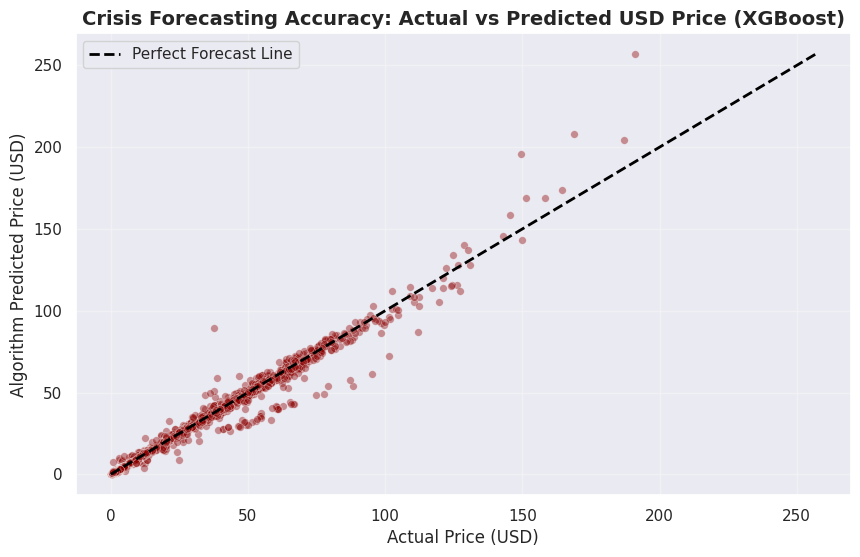


--- 5. ALGORITHMIC DRIVERS (FEATURE IMPORTANCE) ---


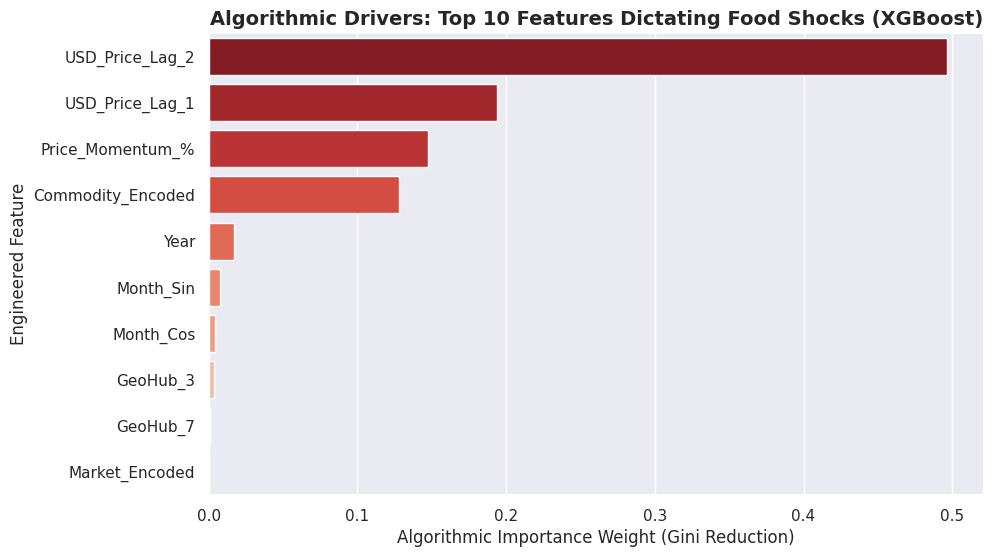

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


print("--- 1. CHRONOLOGICAL DATA SPLITTING ---")

# Since the data is already sorted chronologically from Phase 4
split_idx = int(len(X) * 0.80)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f" Training Set: {len(X_train):,} records (Historical Data)")
print(f" Testing Set: {len(X_test):,} records (Future/Out-of-Sample)")


print("\n--- 2. ALGORITHMIC TRAINING (EARLY WARNING SYSTEM) ---")
# 1. Random Forest (Bagging)
rf_model = RandomForestRegressor(n_estimators=150, max_depth=8, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)

# 2. XGBoost (Boosting)
# We use a lower learning rate to smoothly navigate the extreme hyperinflationary variance
xgb_model = XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1)
xgb_model.fit(X_train, y_train)

print(" Both Regression Architectures successfully trained on historical crisis data.")


print("\n--- 3. OUT-OF-SAMPLE EVALUATION METRICS ---")
# Force the algorithms to predict the unseen future
rf_preds = rf_model.predict(X_test)
xgb_preds = xgb_model.predict(X_test)

def evaluate_regressor(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f" {name} Performance:")
    print(f"   -> Mean Absolute Error (MAE): ${mae:.2f} USD")
    print(f"   -> Root Mean Squared Error (RMSE): ${rmse:.2f} USD")
    print(f"   -> R-Squared (R2): {r2:.4f}")
    return r2, mae

r2_rf, mae_rf = evaluate_regressor("Random Forest", y_test, rf_preds)
print("-" * 40)
r2_xgb, mae_xgb = evaluate_regressor("XGBoost", y_test, xgb_preds)

# Determine the superior architecture
best_model_name = "XGBoost" if r2_xgb > r2_rf else "Random Forest"
best_preds = xgb_preds if r2_xgb > r2_rf else rf_preds
best_model = xgb_model if r2_xgb > r2_rf else rf_model

print(f"\n🏆 The {best_model_name} mathematically outperformed the alternative in forecasting accuracy.")


print("\n--- 4. VISUALIZING THE EARLY WARNING SYSTEM ---")
# How accurately did the algorithm predict the real-world food prices?
# A perfect model creates a straight diagonal line.

plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=best_preds, alpha=0.4, color='darkred', s=30)

# Line of perfect prediction
min_val = min(y_test.min(), best_preds.min())
max_val = max(y_test.max(), best_preds.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--', linewidth=2, label='Perfect Forecast Line')

plt.title(f'Crisis Forecasting Accuracy: Actual vs Predicted USD Price ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price (USD)', fontsize=12)
plt.ylabel('Algorithm Predicted Price (USD)', fontsize=12)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


print("\n--- 5. ALGORITHMIC DRIVERS (FEATURE IMPORTANCE) ---")
# Let's open the black box. What exact mathematical variables dictate a famine-level price spike?

# Extract top 10 features for clean visualization
importances = pd.Series(best_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index, palette='Reds_r')
plt.title(f'Algorithmic Drivers: Top 10 Features Dictating Food Shocks ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Algorithmic Importance Weight (Gini Reduction)', fontsize=12)
plt.ylabel('Engineered Feature', fontsize=12)
plt.show()

# Thank You